**Group 26**

#Lab 3


In [232]:
import numpy as np
import matplotlib.pyplot as plt

## 2.2 Hopfield network recall


In [125]:
def own_sign(x):
   sign = np.sign(x)
   sign[sign == 0] = 1
   return sign

In [233]:
x1=np.array([-1, -1, 1, -1, 1, -1, -1, 1])
x2=np.array([-1, -1, -1, -1, -1, 1, -1 ,-1])
x3=np.array([-1, 1, 1, -1, -1, 1, -1, 1])

weights = np.zeros((len(x1),len(x1)))
x1OP= np.outer(x1,x1)
x2OP = np.outer(x2,x2)
x3OP = np.outer(x3,x3)

weights = x1OP + x2OP + x3OP
print(weights)

[[ 3  1 -1  3  1 -1  3 -1]
 [ 1  3  1  1 -1  1  1  1]
 [-1  1  3 -1  1 -1 -1  3]
 [ 3  1 -1  3  1 -1  3 -1]
 [ 1 -1  1  1  3 -3  1  1]
 [-1  1 -1 -1 -3  3 -1 -1]
 [ 3  1 -1  3  1 -1  3 -1]
 [-1  1  3 -1  1 -1 -1  3]]


In [234]:
test1= own_sign(weights @ x1)
assert np.array_equal(x1,test1)

test2= own_sign(weights @ x2)
assert np.array_equal(x2,test2)

test3= own_sign(weights @ x3)
assert np.array_equal(x3,test3)

## 3.1 Convergence and attractors

In [235]:
x1d = np.array([1, -1, 1, -1, 1, -1, -1, 1])
x2d = np.array([1, 1, -1, -1, -1, 1, -1, -1])
x3d = np.array([1, 1, 1, -1, 1, 1, -1, 1])
xs = [x1,x2,x3]
xsd=[x1d,x2d,x3d]

for xd, x in zip(xsd,xs):
  x_old = np.zeros(len(xd))
  while(not np.array_equal(xd,x_old)):
    x_old = xd
    xd = own_sign(weights @ xd)
  print(xd)
  if np.array_equal(xd,x):
    print("Converged")
  else:
    print("Not converged")

[-1 -1  1 -1  1 -1 -1  1]
Converged
[-1  1 -1 -1 -1  1 -1 -1]
Not converged
[-1  1  1 -1 -1  1 -1  1]
Converged


In [236]:
x_values = [1, -1]
n_attractors = 0
for x_1 in x_values:
  for x_2 in x_values:
    for x_3 in x_values:
      for x_4 in x_values:
        for x_5 in x_values:
          for x_6 in x_values:
            for x_7 in x_values:
              for x_8 in x_values:
                x = np.array([x_1, x_2, x_3, x_4, x_5, x_6, x_7, x_8])
                x_new = own_sign(weights @ x)
                if np.array_equal(x_new, x):
                  n_attractors += 1
                  print(x)
print(n_attractors)

[ 1  1  1  1  1 -1  1  1]
[ 1  1  1  1 -1  1  1  1]
[ 1  1 -1  1  1  1  1 -1]
[ 1  1 -1  1  1 -1  1 -1]
[ 1  1 -1  1 -1  1  1 -1]
[ 1 -1 -1  1  1 -1  1 -1]
[-1  1  1 -1  1 -1 -1  1]
[-1  1  1 -1 -1  1 -1  1]
[-1  1 -1 -1 -1  1 -1 -1]
[-1 -1  1 -1  1  1 -1  1]
[-1 -1  1 -1  1 -1 -1  1]
[-1 -1  1 -1 -1  1 -1  1]
[-1 -1 -1 -1  1 -1 -1 -1]
[-1 -1 -1 -1 -1  1 -1 -1]
14


In [237]:
x1dd = np.array([1, 1, -1, 1, 1, -1, -1, 1])
x2dd = np.array([1, 1, 1, 1, -1, 1, -1, -1])
x3dd = np.array([1, -1, -1, 1, -1, 1, -1, 1])
xsdd=[x1dd,x2dd,x3dd]

for xd, x in zip(xsdd,xs):
  x_old = np.zeros(len(xd))
  while(not np.array_equal(xd,x_old)):
    x_old = xd
    xd = own_sign(weights @ xd)
  print(xd)
  if np.array_equal(xd,x):
    print("Converged")
  else:
    print("Not converged")

[ 1  1  1  1  1 -1  1  1]
Not converged
[ 1  1 -1  1 -1  1  1 -1]
Not converged
[ 1  1 -1  1 -1  1  1 -1]
Not converged


##3.2 Sequential Update

In [238]:
data = np.loadtxt('pict.dat',delimiter=',')
data = data.reshape(11,1024)

p1= data[0,:]
p2= data[1,:]
p3= data[2,:]

weights = np.outer(p1,p1) + np.outer(p2,p2)+ np.outer(p3,p3)


In [239]:
test1= own_sign(weights @ p1)
assert np.array_equal(p1,test1)

test2= own_sign(weights @ p2)
assert np.array_equal(p2,test2)

test3= own_sign(weights @ p3)
assert np.array_equal(p3,test3)

In [240]:
p10 = data[9,:]
p11 = data[10,:]

pp = p10
p_old = np.zeros(len(p10))
while(not np.array_equal(pp,p_old)):
  p_old = pp
  pp = own_sign(weights @ pp)

if np.array_equal(pp,p1): print("P10 converged to P1")

pp = p11
p_old = np.zeros(len(p11))
while(not np.array_equal(pp,p_old)):
  p_old = pp
  pp = own_sign(weights @ pp)

if np.array_equal(pp,p2): print("P11 converged to P2")
if np.array_equal(pp,p3): print("P11 converged to P3")
else: print("P11 did not converge")


P10 converged to P1
P11 did not converge


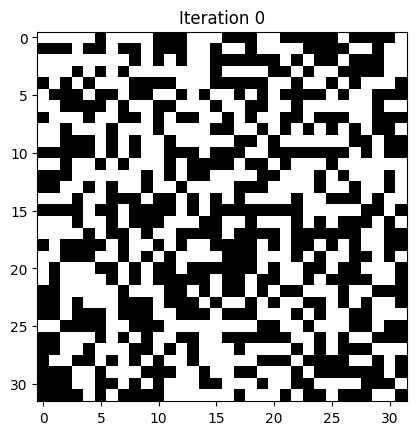

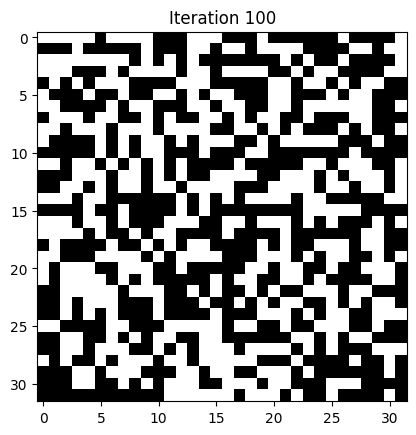

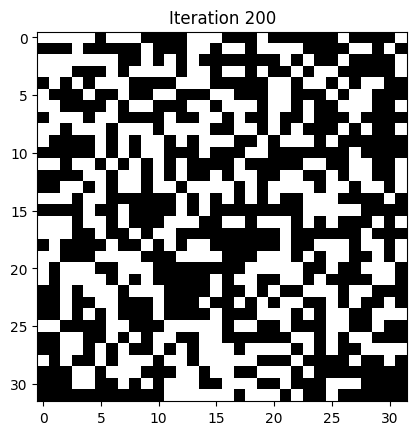

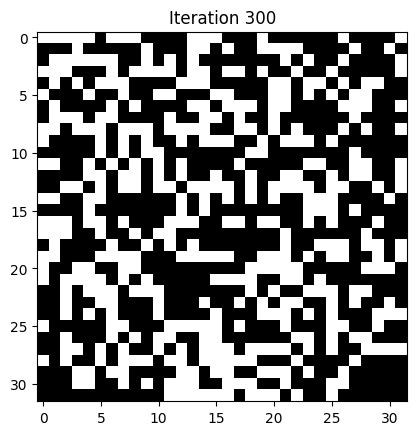

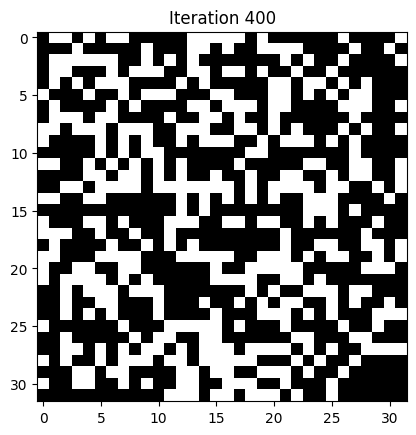

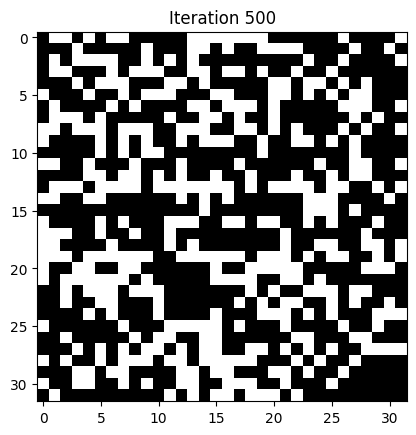

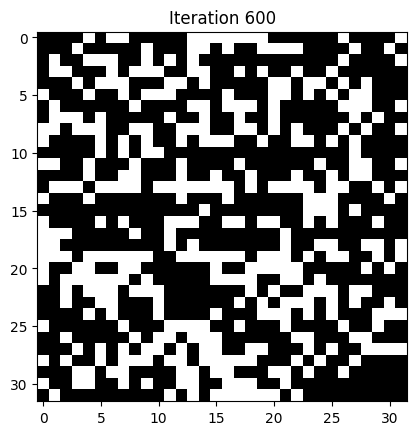

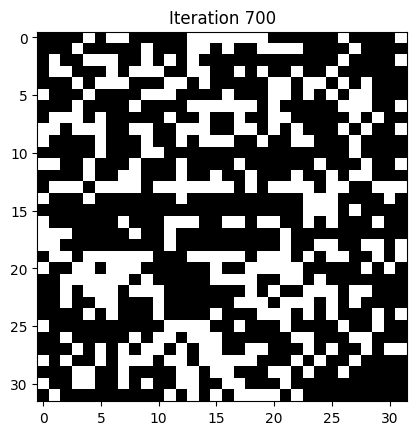

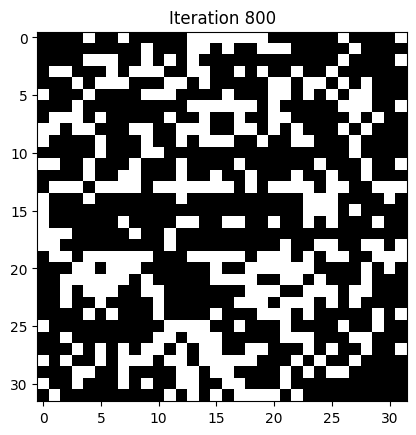

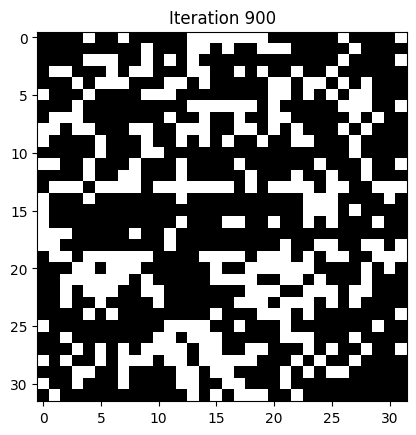

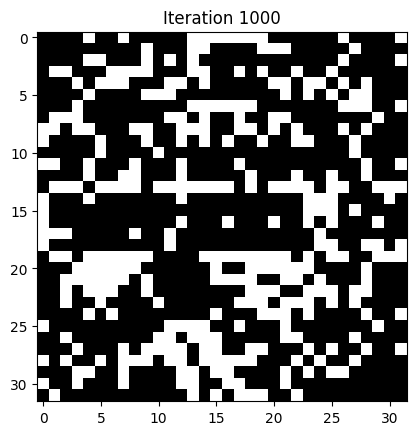

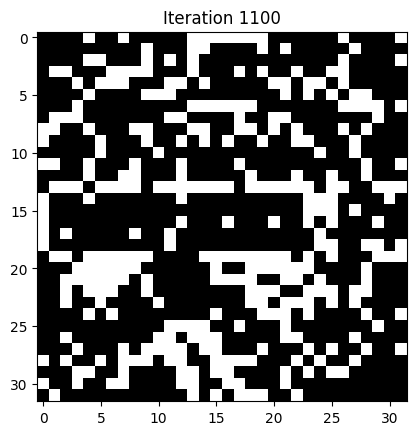

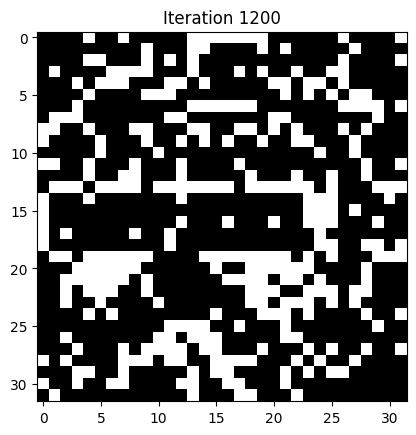

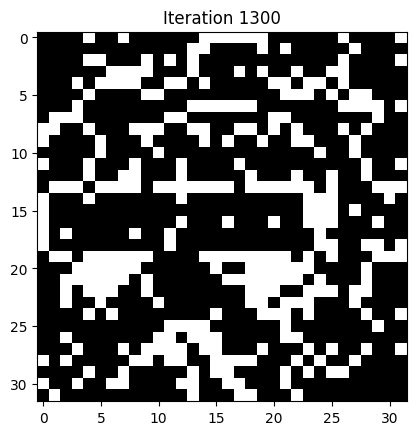

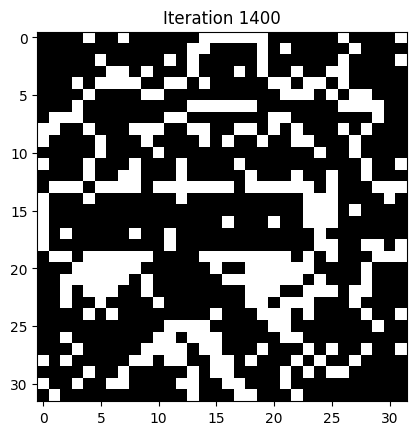

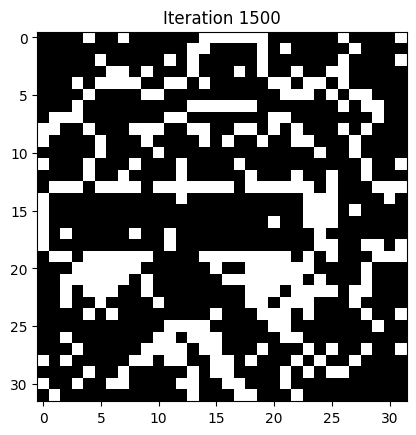

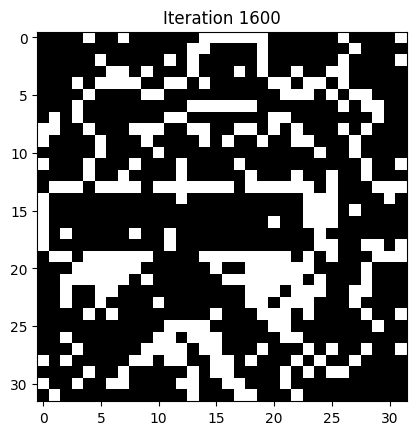

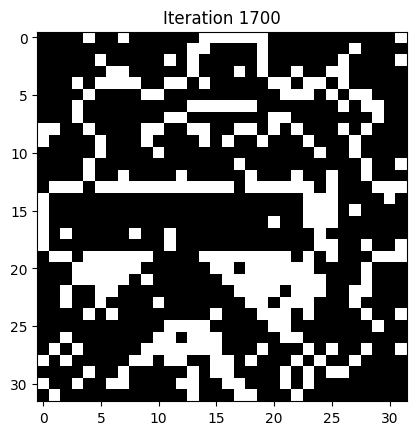

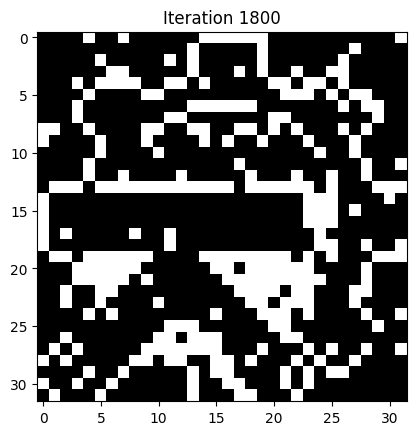

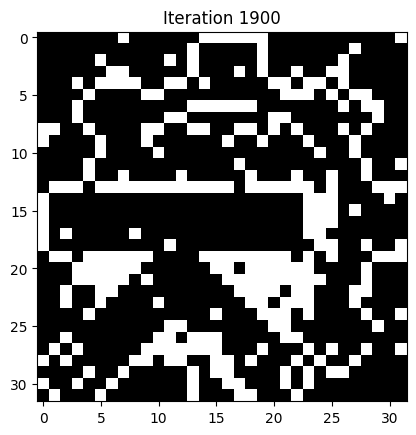

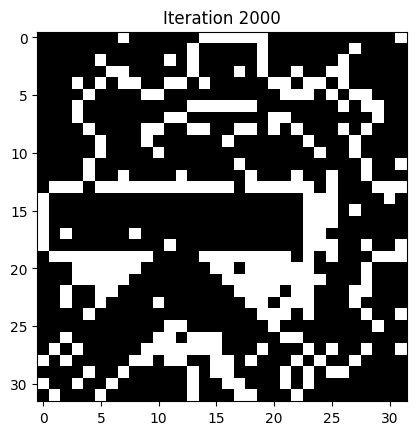

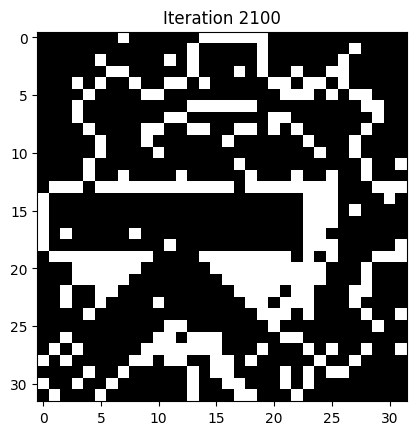

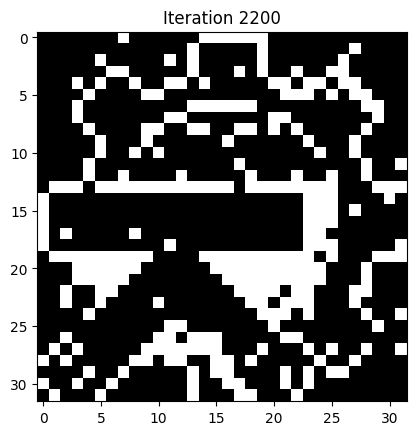

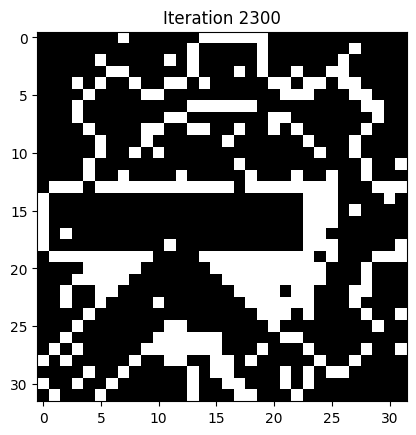

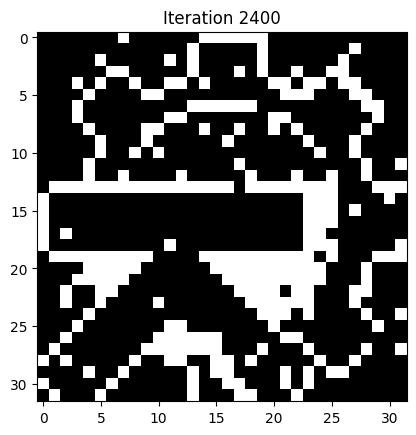

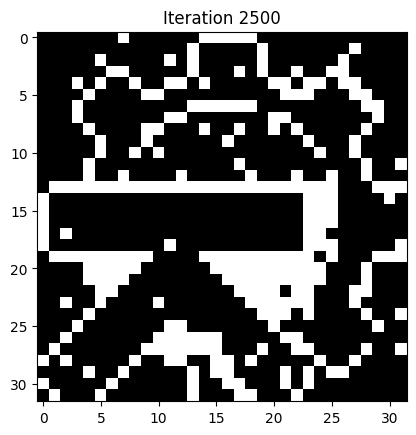

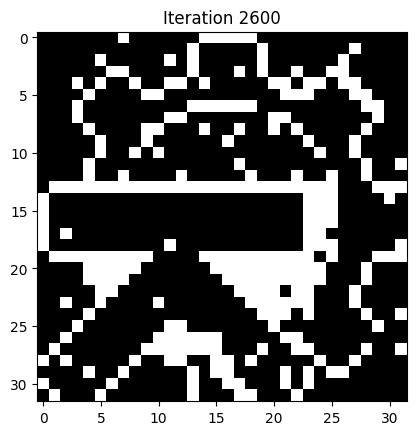

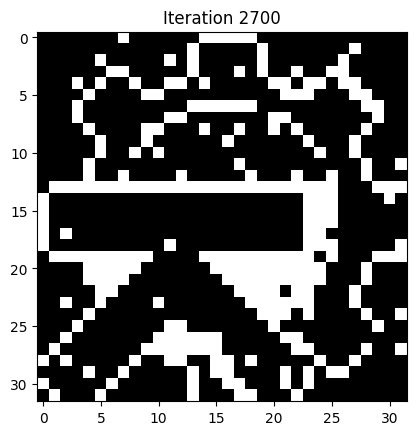

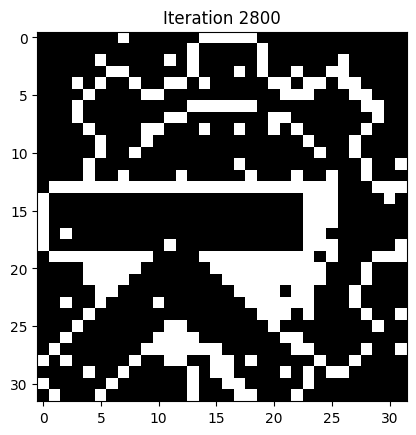

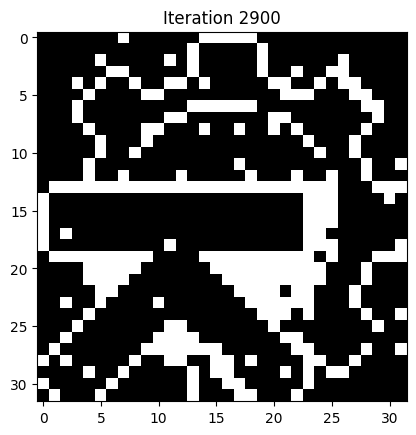

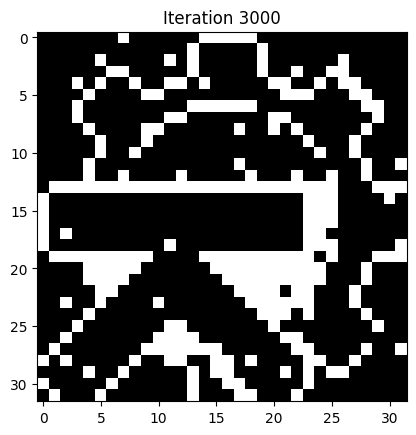

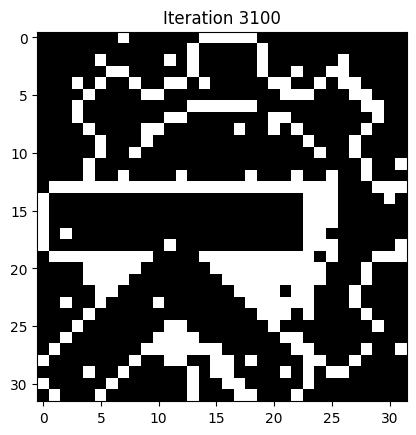

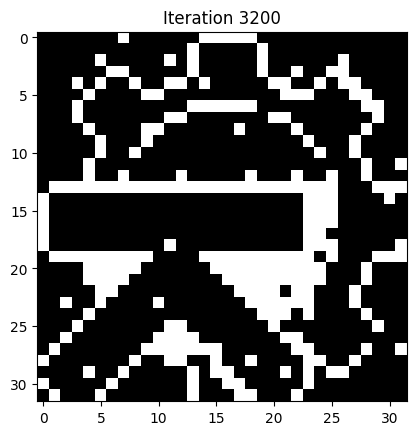

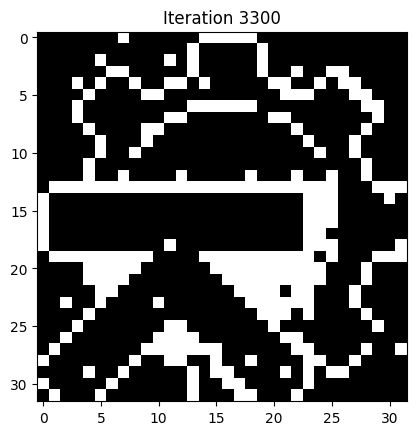

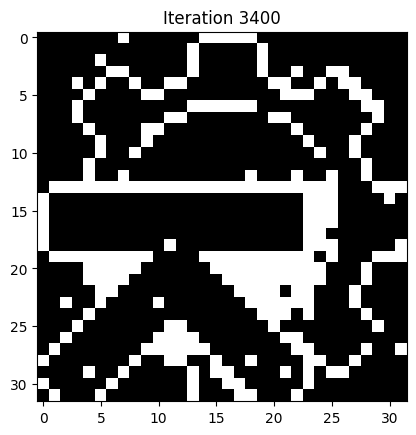

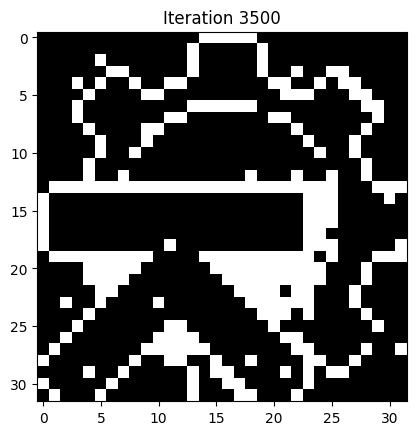

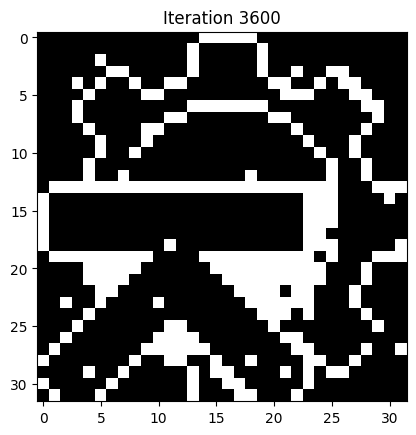

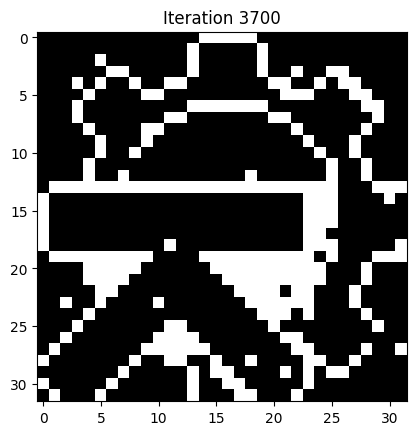

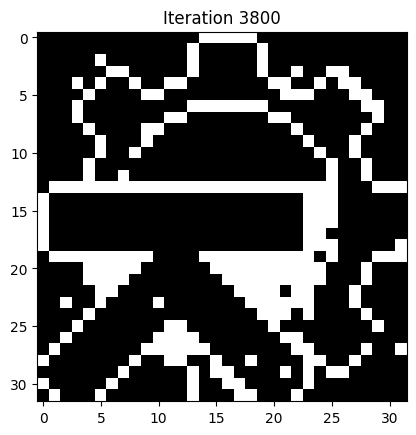

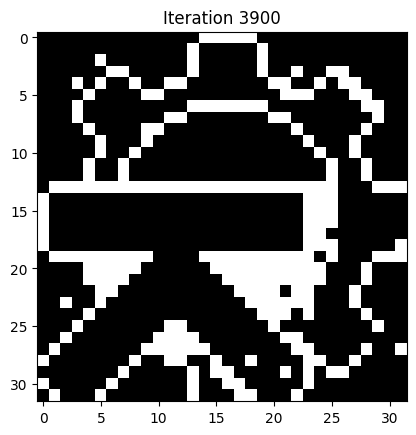

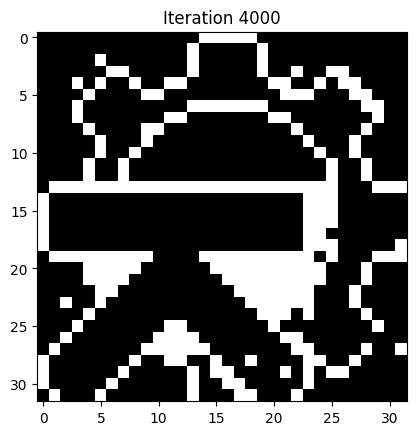

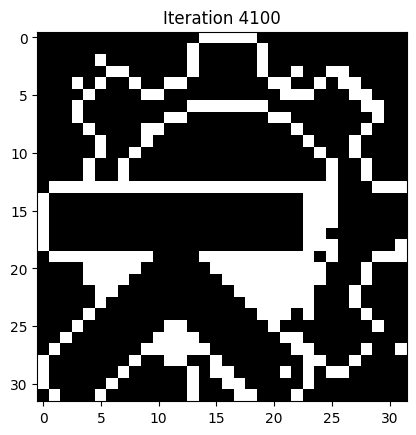

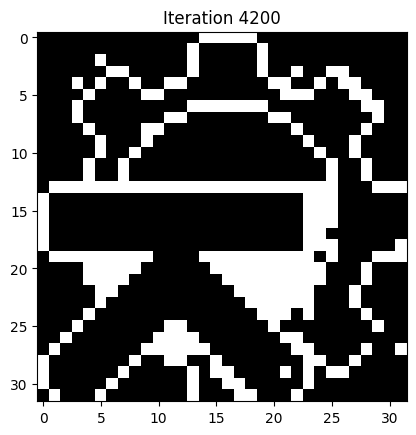

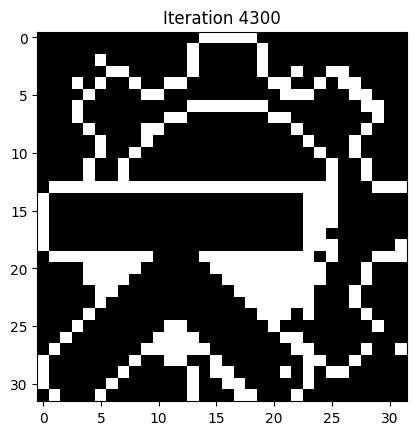

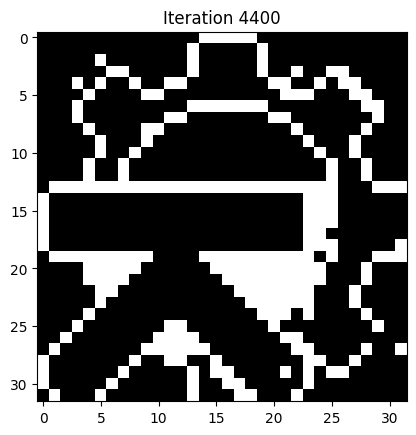

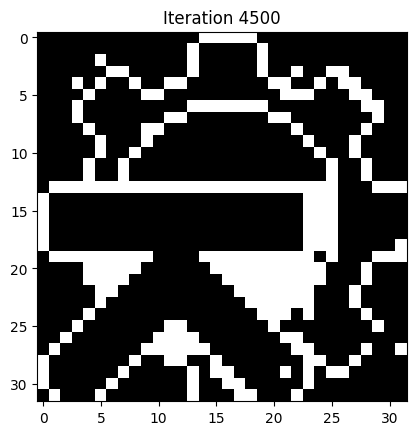

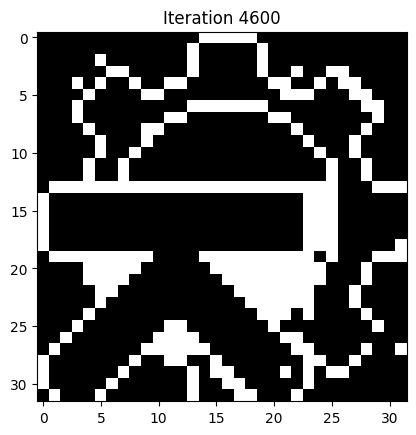

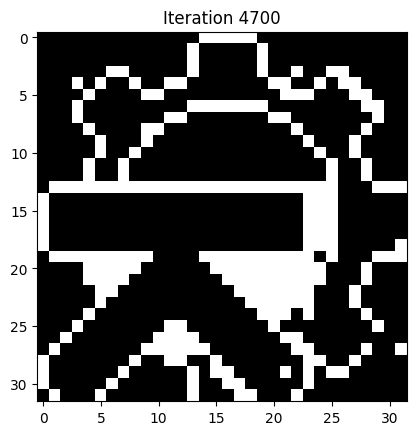

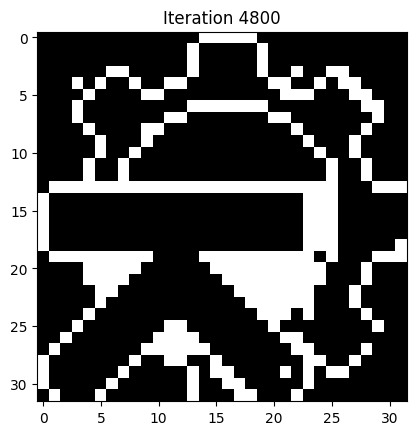

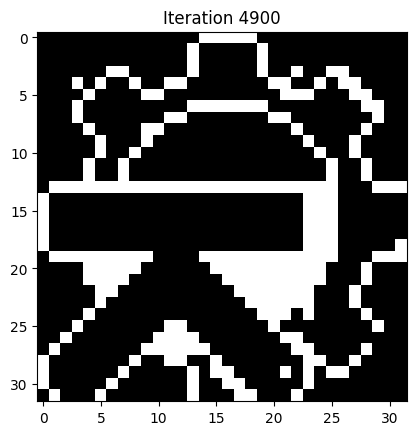

In [153]:
p_random = own_sign(np.random.uniform(-1,1,1024))

epochs = 5000
for i in range(epochs):
  idx=np.random.randint(0,1024)
  p_random[idx] = own_sign(weights @ p_random)[idx]
  if i % 100 == 0:
        plt.imshow(p_random.reshape(32, 32), cmap='gray')
        plt.title(f"Iteration {i}")
        plt.show()

##3.3 Energy

In [241]:
def calculate_energy(weights, x):
    energy = - np.sum(weights * np.outer(x, x))
    return energy

In [242]:
print('Energy P1=', calculate_energy(weights, p1))
print('Energy P2=', calculate_energy(weights, p2))
print('Energy P3=', calculate_energy(weights, p3))
print('Energy P10=', calculate_energy(weights, p10))
print('Energy P11=', calculate_energy(weights, p11))


Energy P1= -1473936.0
Energy P2= -1398416.0
Energy P3= -1497344.0
Energy P10= -425964.0
Energy P11= -177664.0


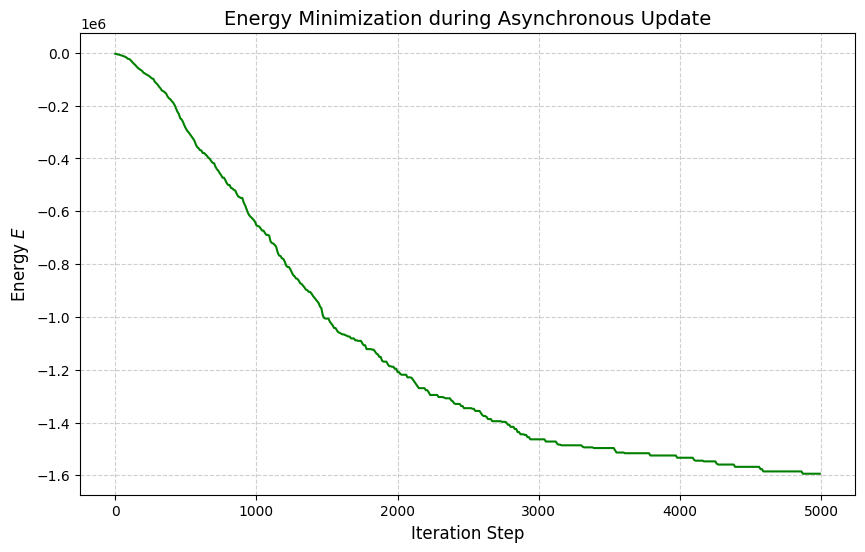

In [247]:
p_random = own_sign(np.random.uniform(-1,1,1024))

epochs = 5000
energy_history = []
iterations = []
for i in range(epochs):
  idx=np.random.randint(0,1024)
  p_random[idx] = own_sign(weights @ p_random)[idx]
  if i % 10 == 0:
        current_energy = calculate_energy(weights, p_random)
        energy_history.append(current_energy)
        iterations.append(i)

plt.figure(figsize=(10, 6))
plt.plot(iterations, energy_history, color='green', linewidth=1.5)

plt.title('Energy Minimization during Asynchronous Update', fontsize=14)
plt.xlabel('Iteration Step', fontsize=12)
plt.ylabel('Energy $E$', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

energy goes down constantly

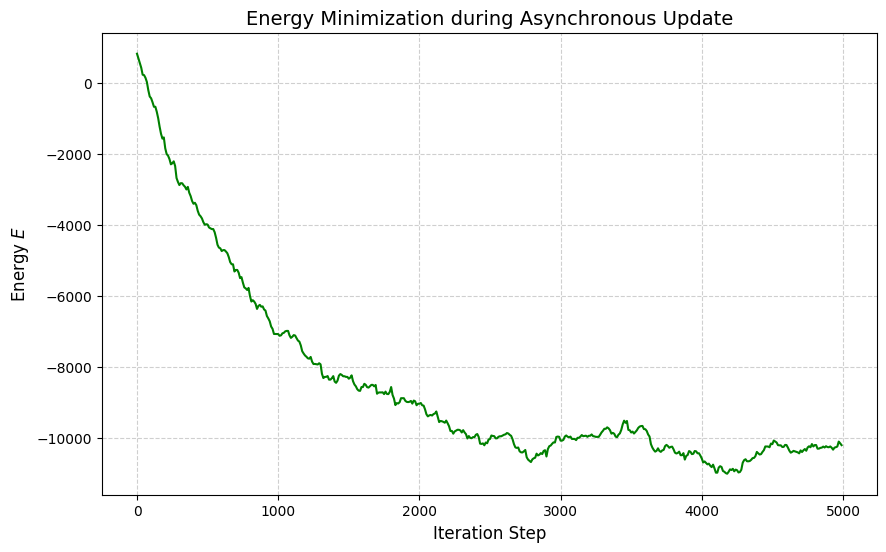

In [251]:
p_random = own_sign(np.random.uniform(-1,1,1024))
weights_random = np.random.uniform(-1,1,(1024,1024))
epochs = 5000
energy_history = []
iterations = []
for i in range(epochs):
  idx=np.random.randint(0,1024)
  p_random[idx] = own_sign(weights_random @ p_random)[idx]
  if i % 10 == 0:
        current_energy = calculate_energy(weights_random, p_random)
        energy_history.append(current_energy)
        iterations.append(i)

plt.figure(figsize=(10, 6))
plt.plot(iterations, energy_history, color='green', linewidth=1.5)

plt.title('Energy Minimization during Asynchronous Update', fontsize=14)
plt.xlabel('Iteration Step', fontsize=12)
plt.ylabel('Energy $E$', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

energy doesn't go down but fluctuates arroung a relatively high value

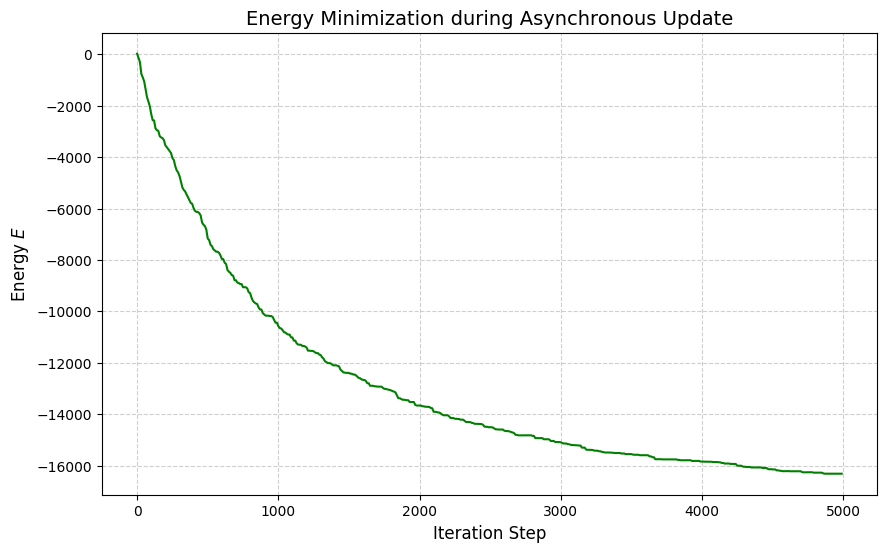

In [253]:
p_random = own_sign(np.random.uniform(-1,1,1024))
weights_random = np.random.uniform(-1,1,(1024,1024))
weights_random=0.5 * (weights_random + weights_random.T)
energy_history = []
iterations = []
epochs = 5000
for i in range(epochs):
  idx=np.random.randint(0,1024)
  p_random[idx] = own_sign(weights_random @ p_random)[idx]
  if i % 10 == 0:
        current_energy = calculate_energy(weights_random, p_random)
        energy_history.append(current_energy)
        iterations.append(i)

plt.figure(figsize=(10, 6))
plt.plot(iterations, energy_history, color='green', linewidth=1.5)

plt.title('Energy Minimization during Asynchronous Update', fontsize=14)
plt.xlabel('Iteration Step', fontsize=12)
plt.ylabel('Energy $E$', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Energy goes down constalntly because now we have a legitimate weight matrix representing a Hopfield network with attractor even if they are random.

## 3.4 Distortion Resistance

In [179]:
data = np.loadtxt('pict.dat',delimiter=',')
data = data.reshape(11,1024)

p1= data[0,:]
p2= data[1,:]
p3= data[2,:]

weights = np.outer(p1,p1) + np.outer(p2,p2)+ np.outer(p3,p3)


In [180]:
def add_noise(pattern, noise_procent):
    noisy_pattern = np.copy(pattern)
    n_pixels = len(pattern)

    n_flip = int(noise_procent/100 * n_pixels)

    flip_indices = np.random.choice(n_pixels, n_flip, replace=False)

    noisy_pattern[flip_indices] *= -1

    return noisy_pattern

Next P


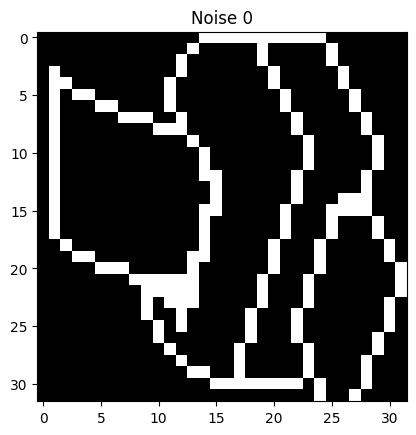

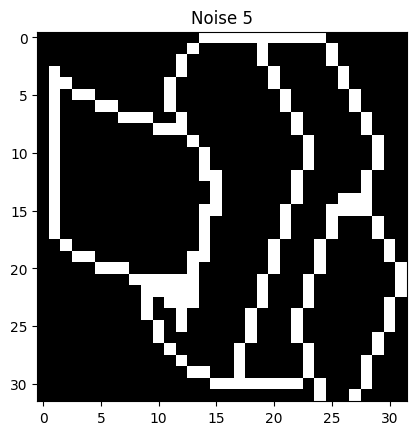

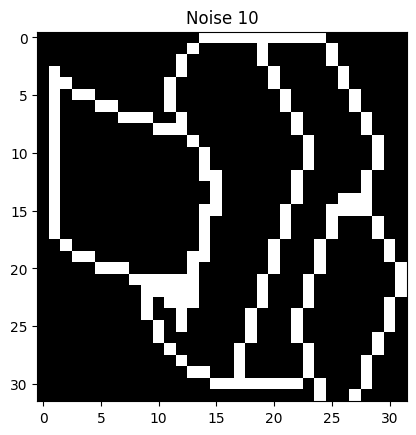

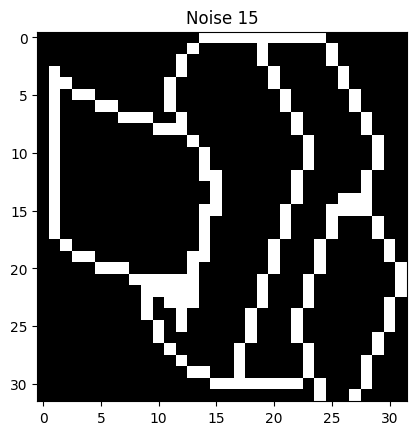

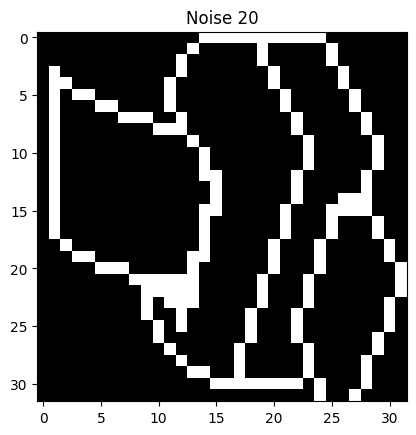

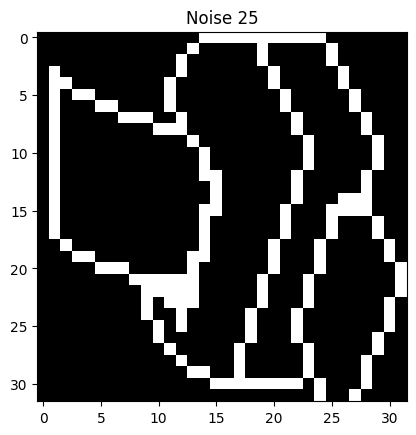

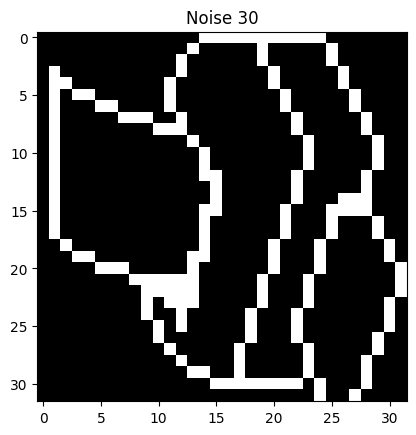

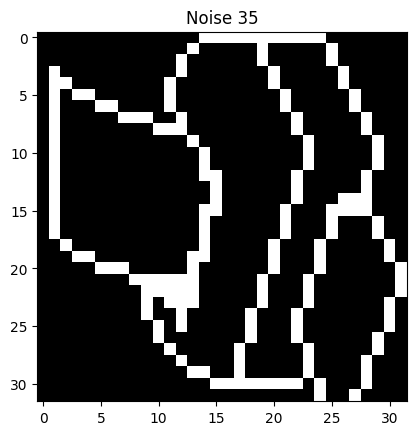

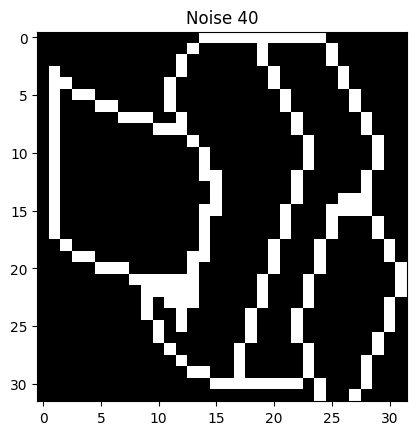

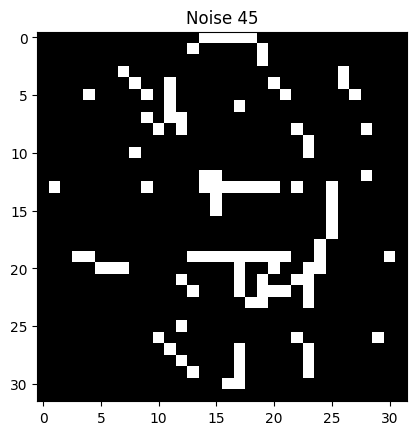

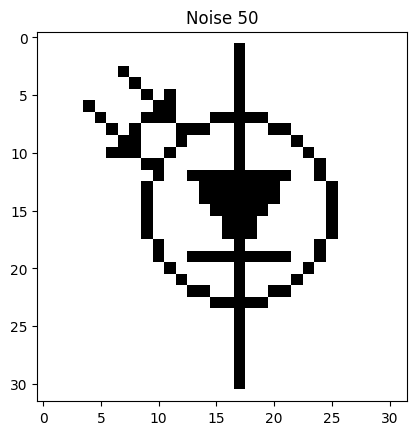

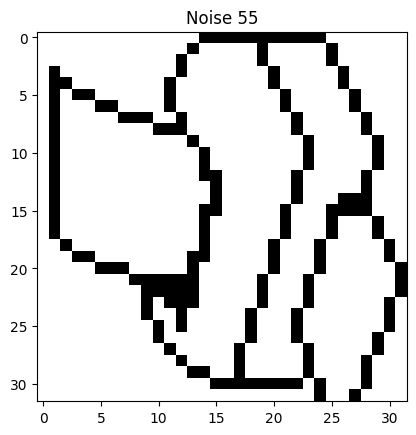

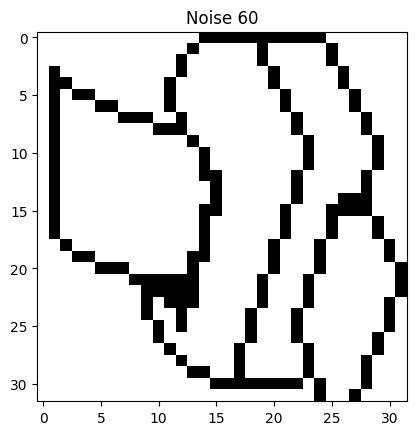

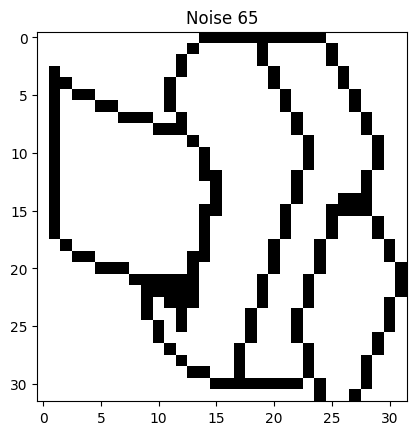

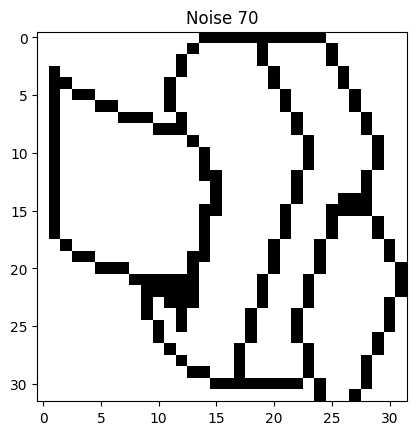

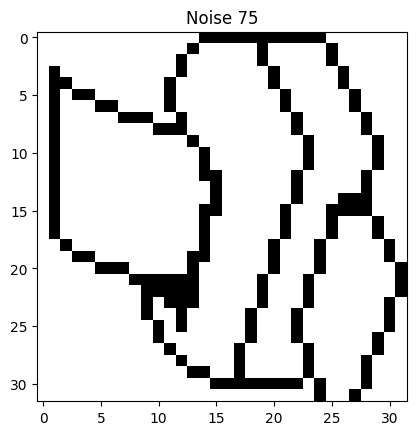

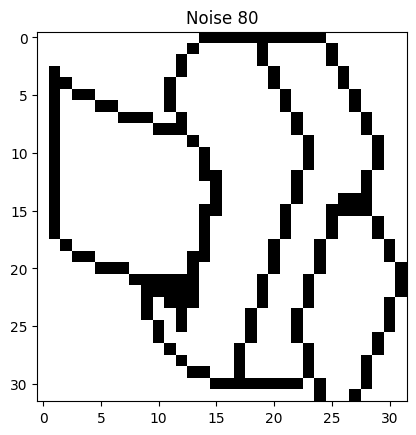

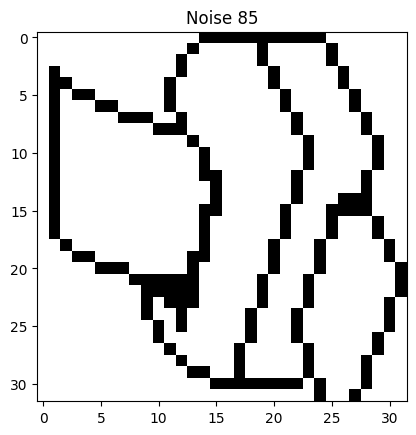

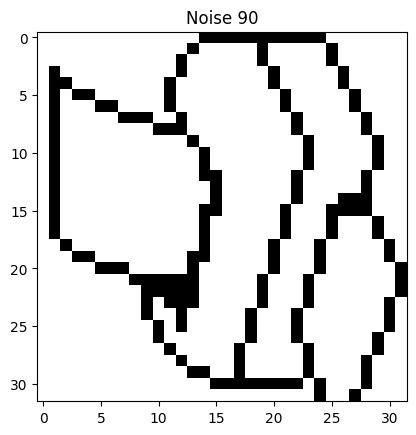

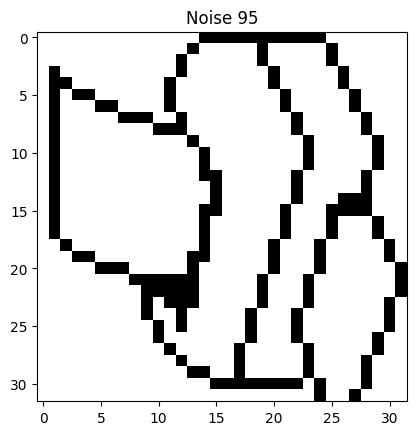

Next P


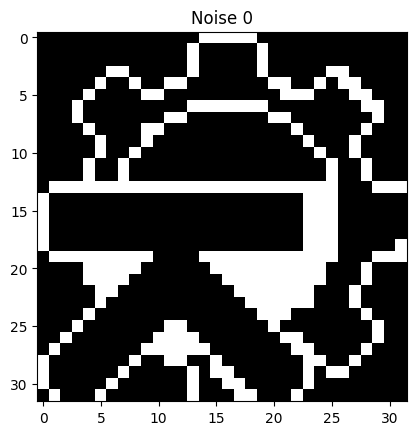

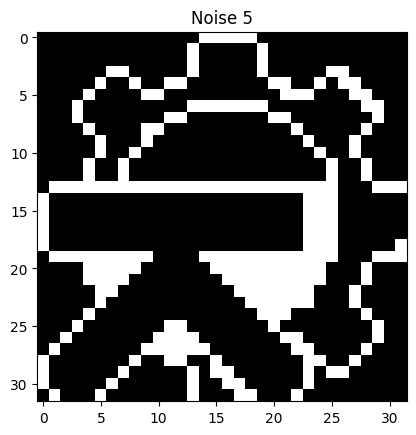

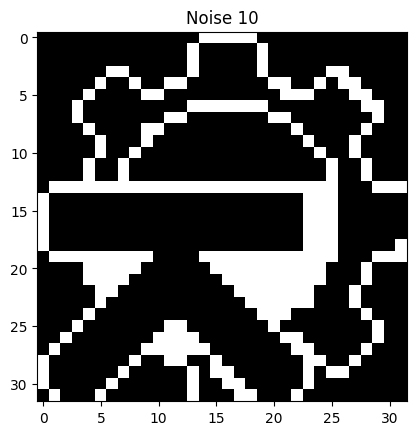

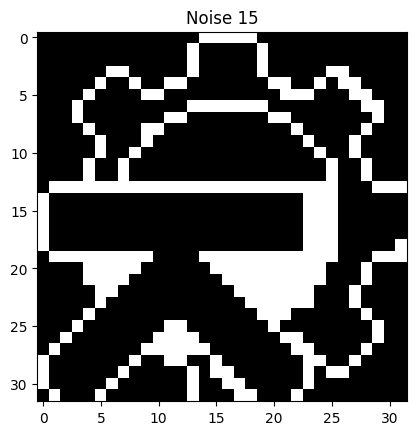

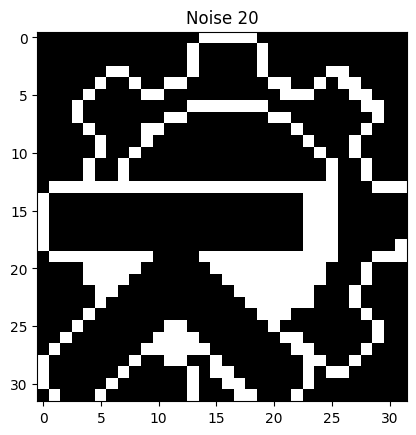

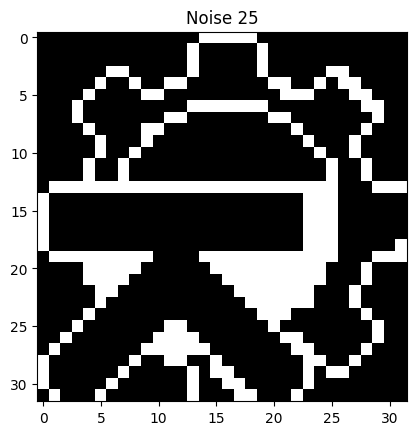

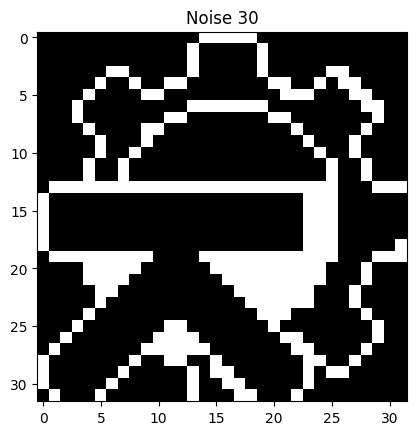

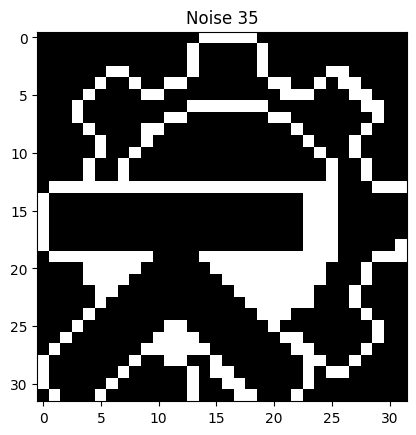

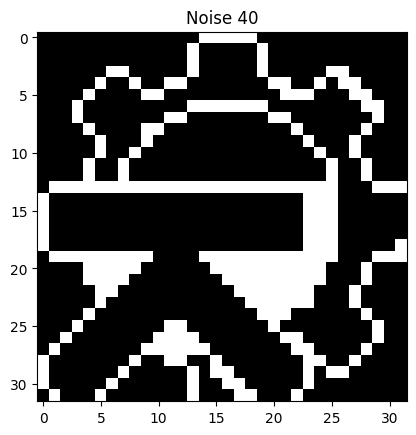

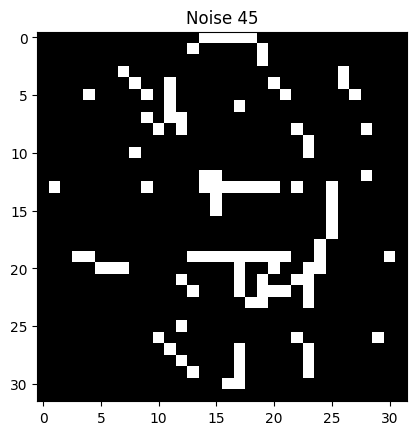

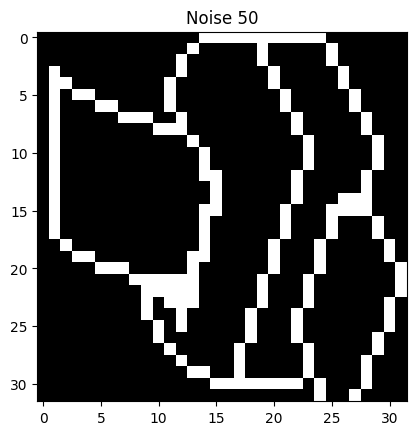

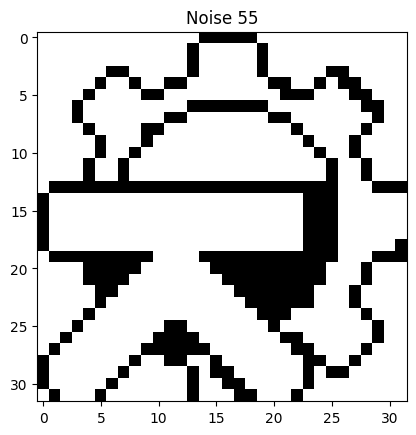

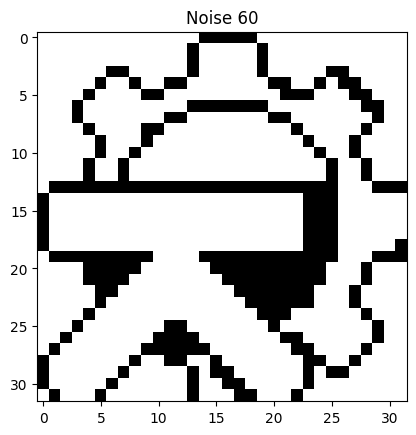

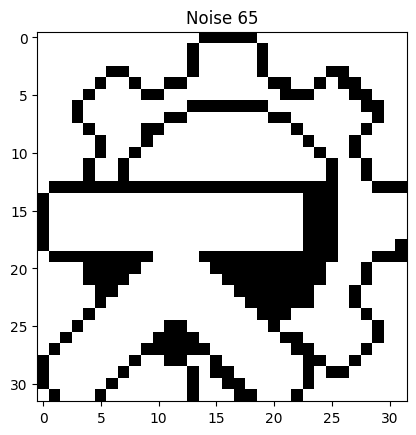

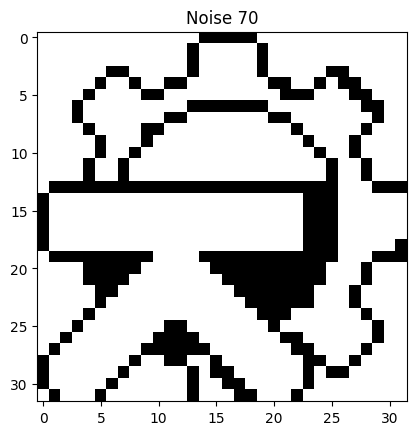

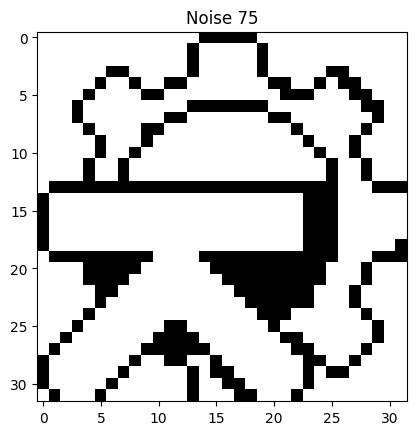

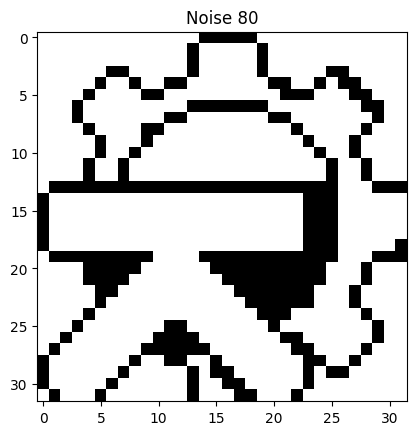

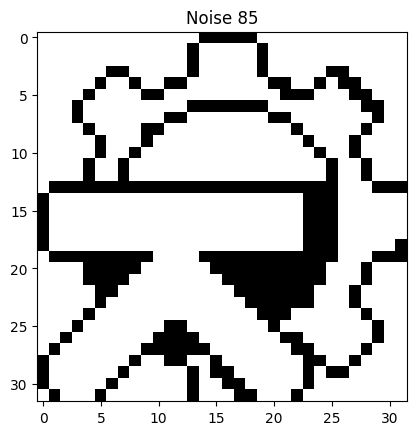

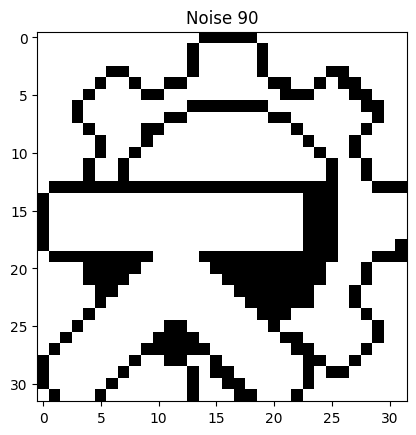

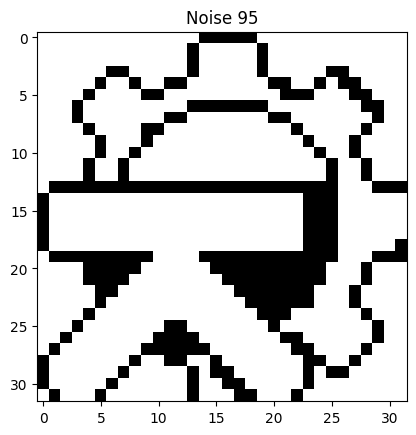

Next P


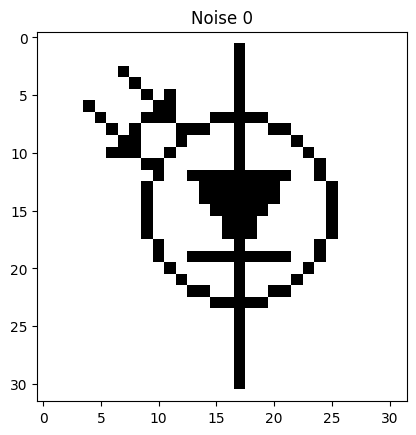

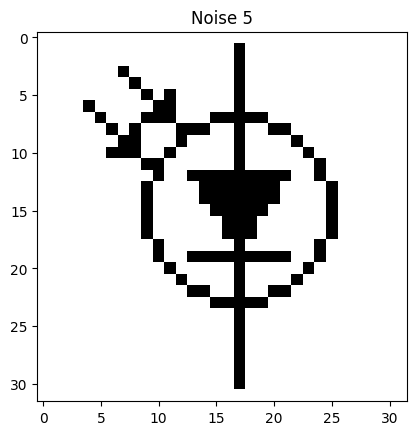

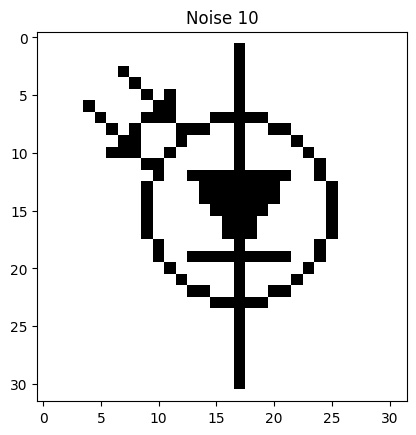

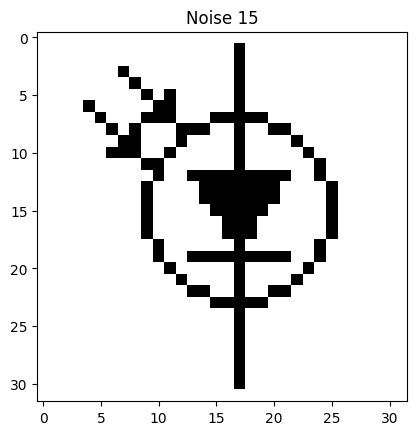

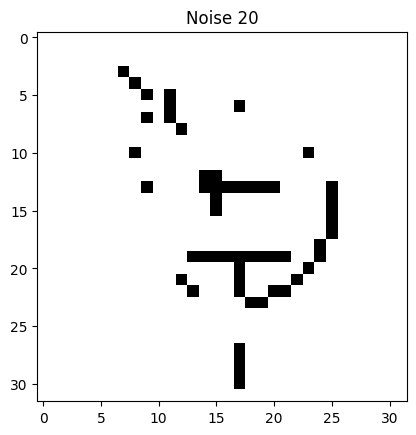

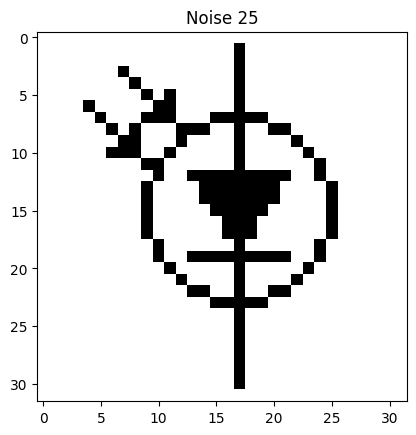

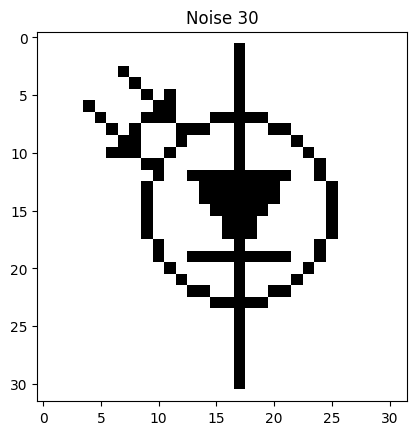

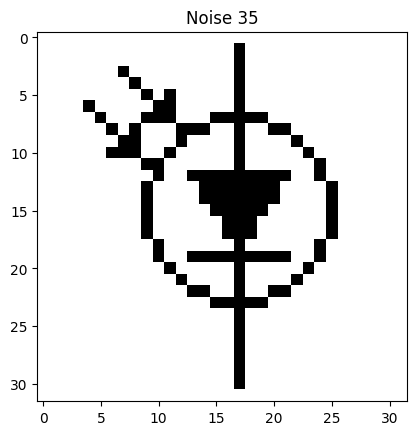

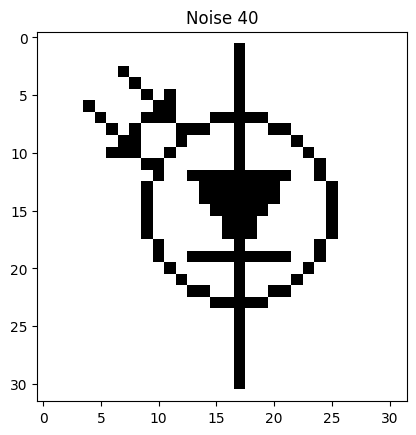

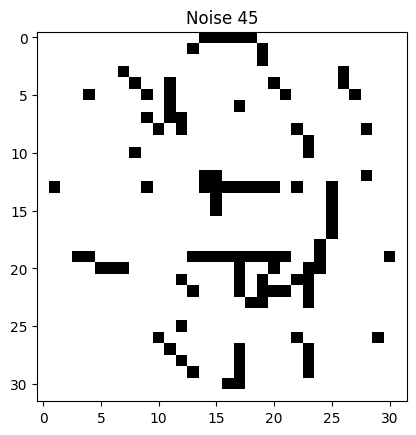

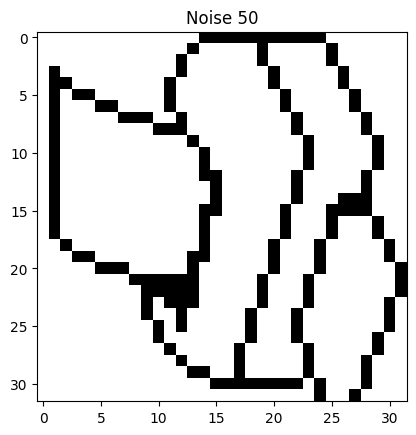

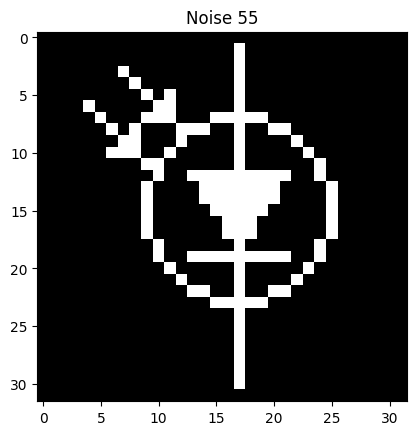

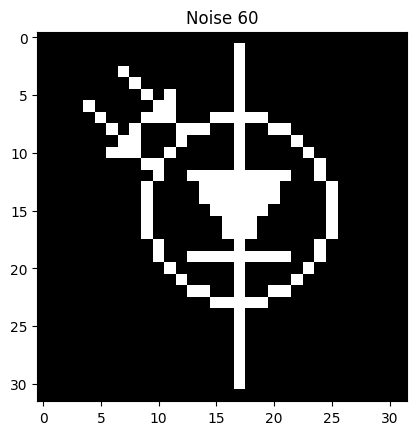

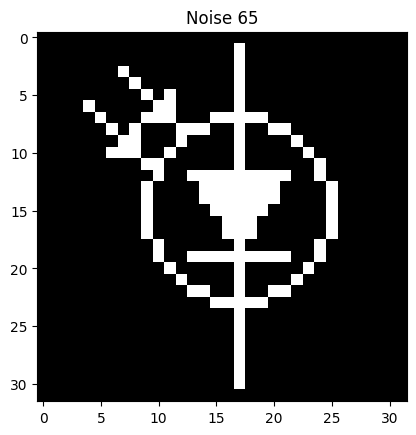

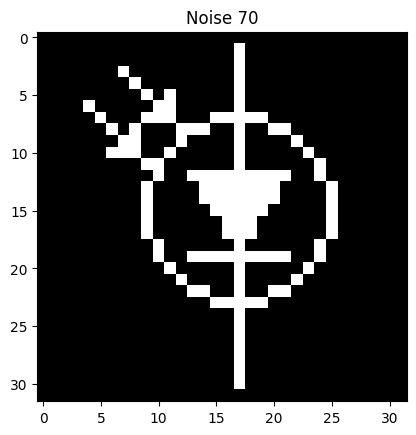

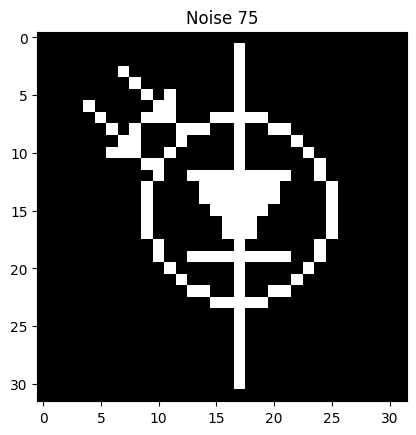

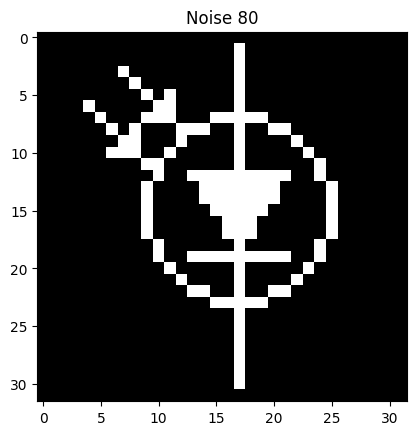

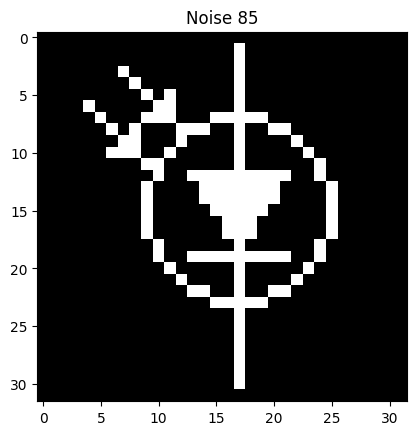

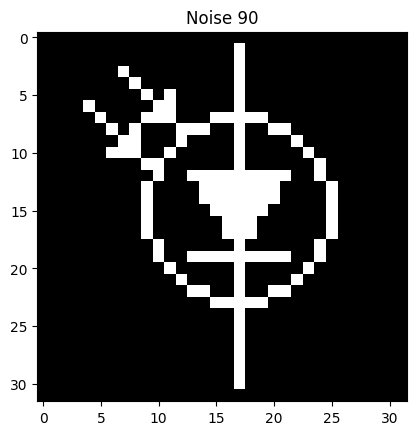

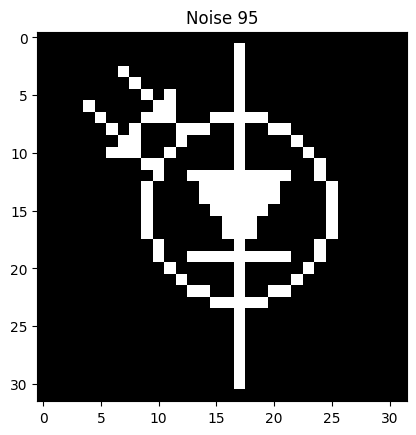

In [181]:
for p in [p1,p2,p3]:
  print('Next P')
  for n in range(0,100,5):
    p_noise = add_noise(p, n)
    p_noise = own_sign(weights @ p_noise)
    plt.imshow(p_noise.reshape(32, 32), cmap='gray')
    plt.title(f"Noise {n}")
    plt.show()

Around 30% or more than 70% because then the picture just gets inverted. The seocnd patten seems more stabel but  not super much and it also depends on the run

Next P


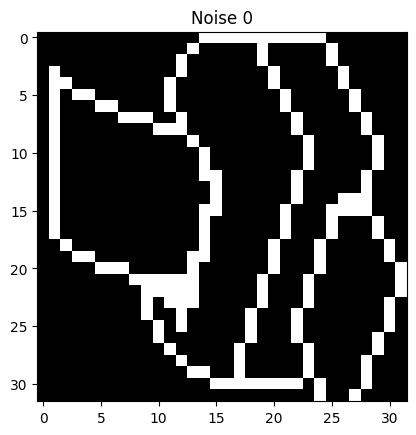

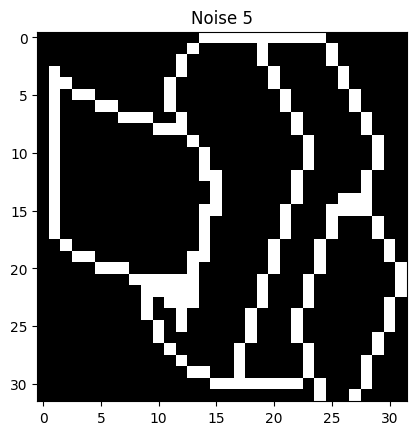

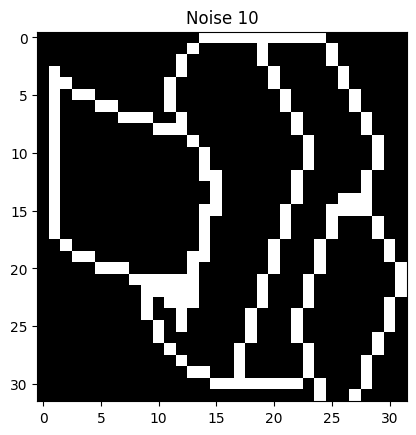

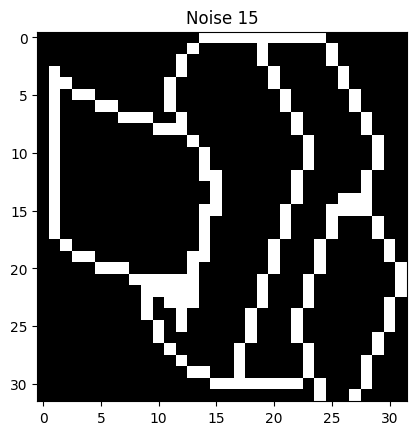

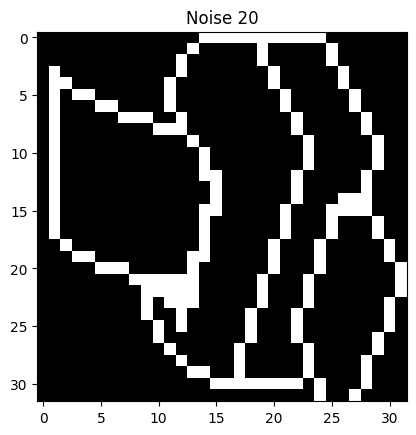

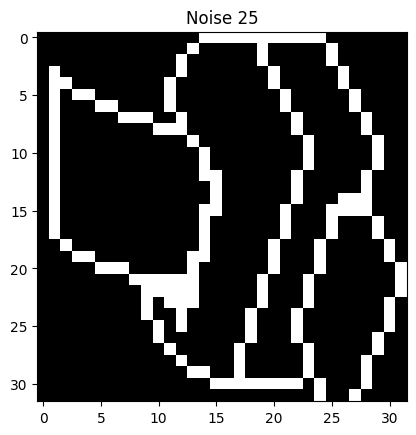

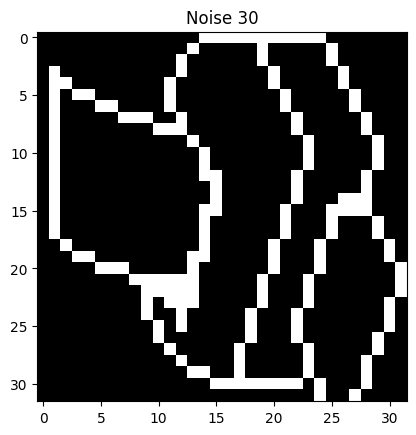

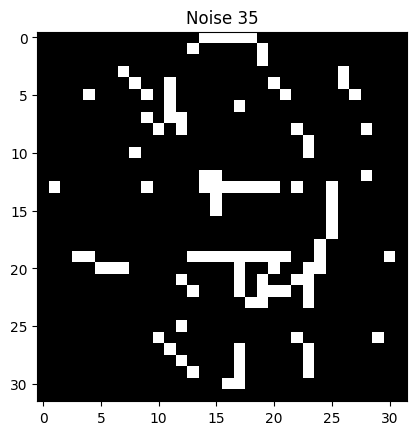

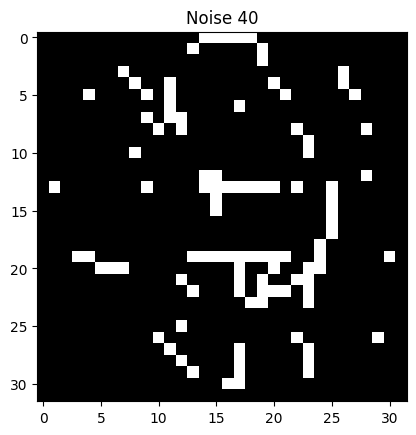

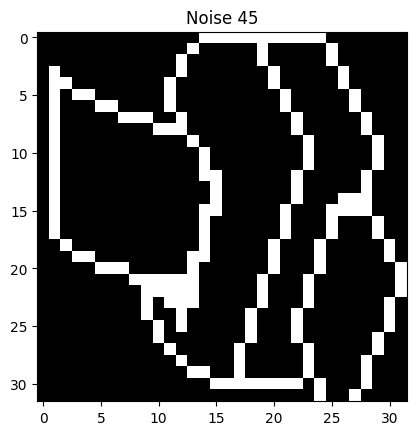

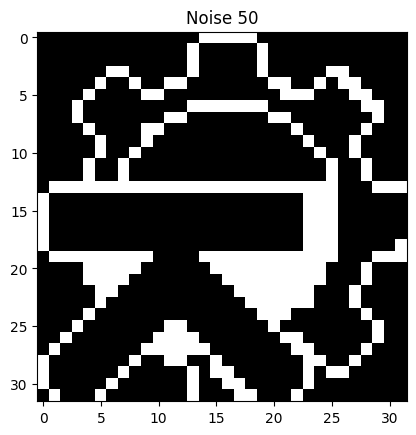

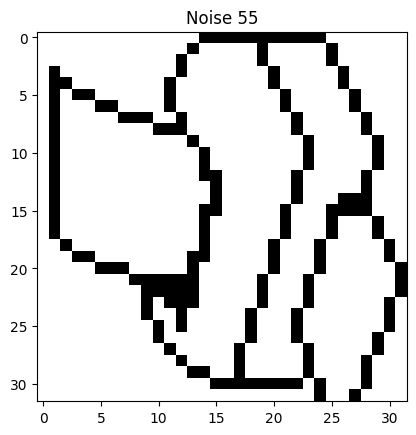

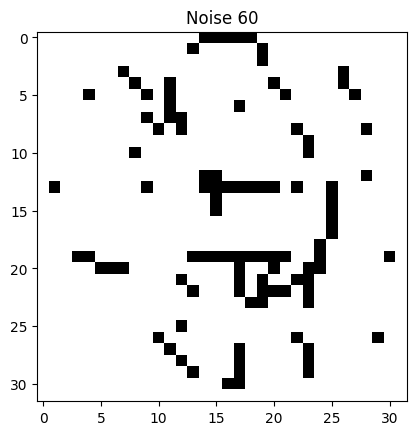

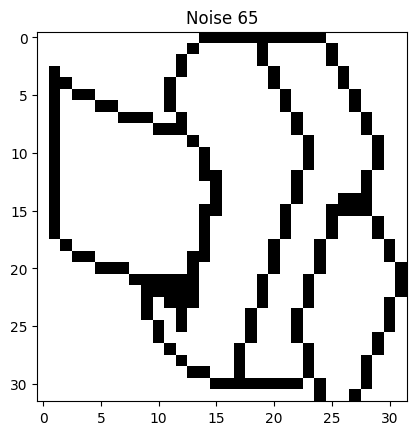

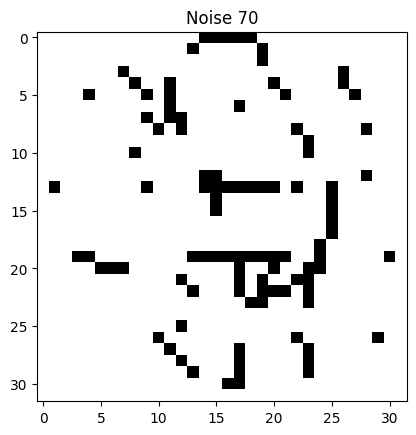

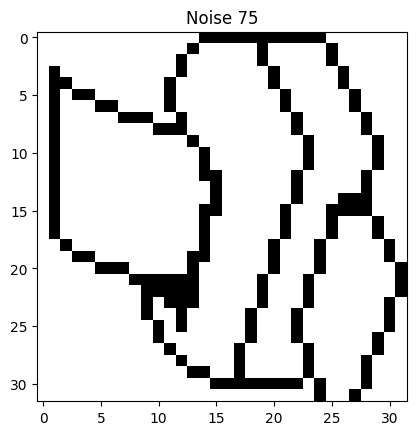

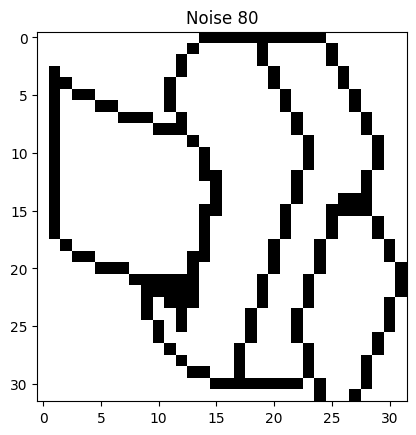

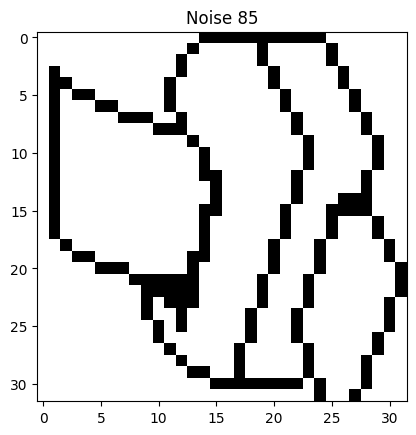

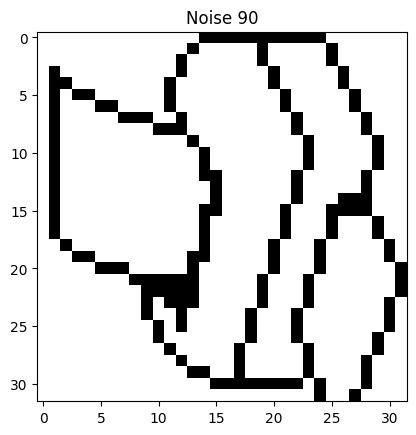

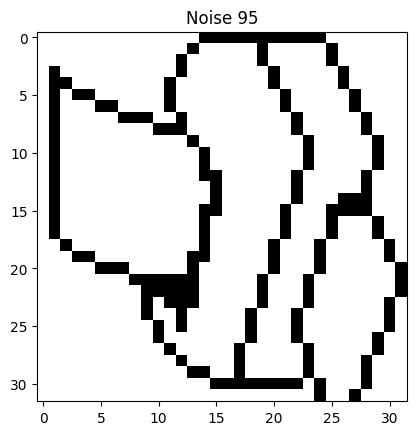

Next P


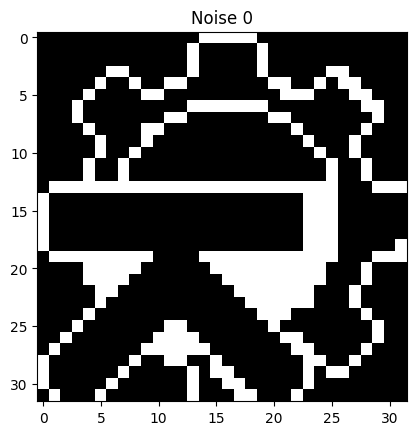

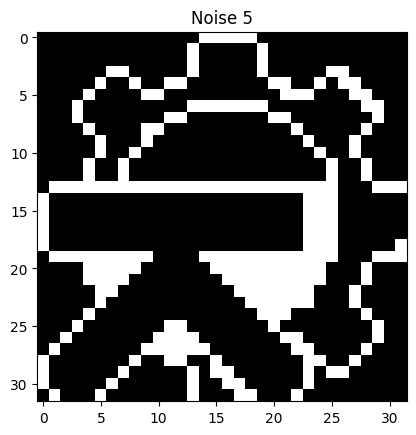

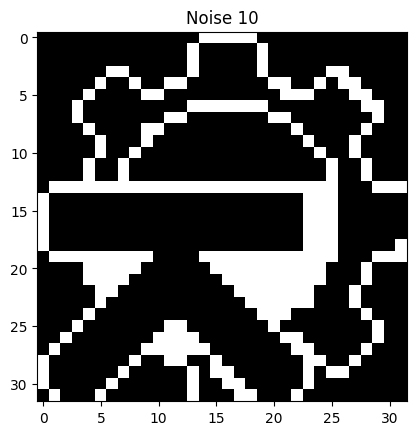

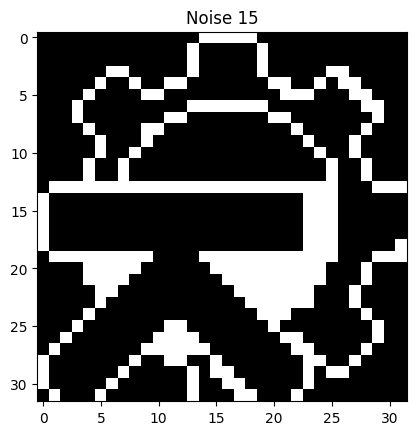

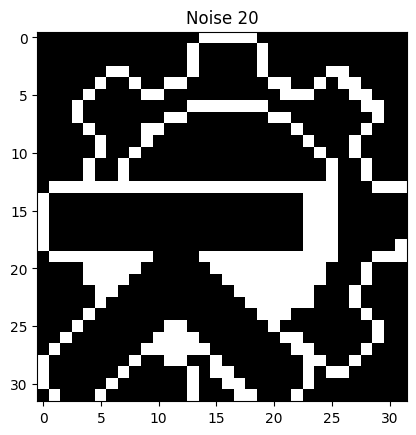

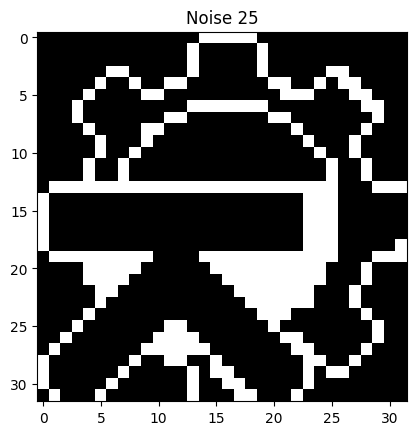

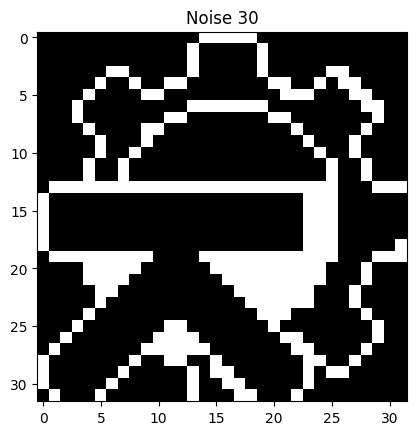

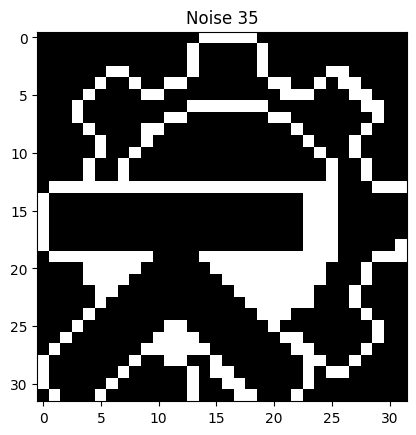

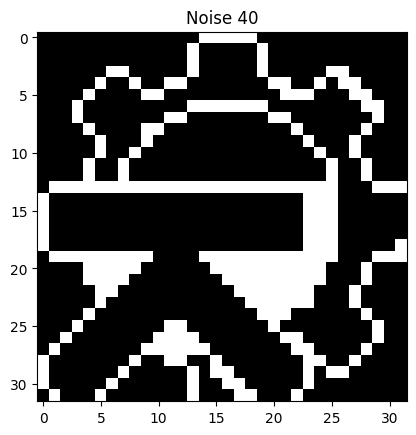

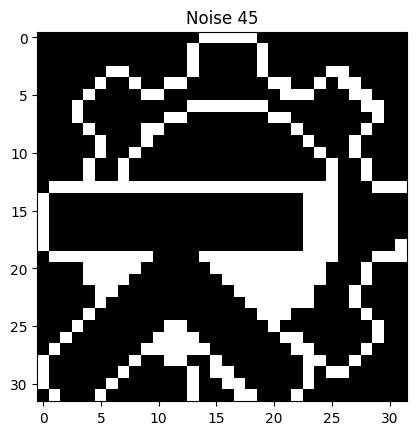

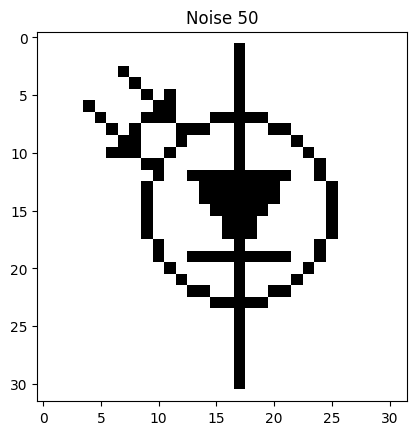

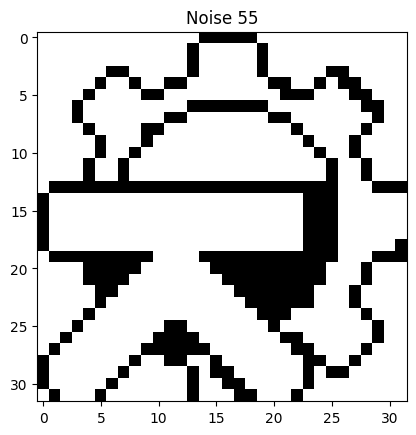

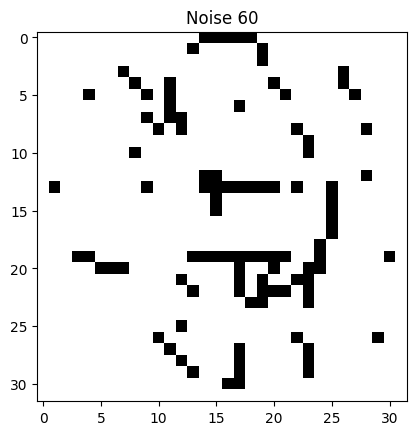

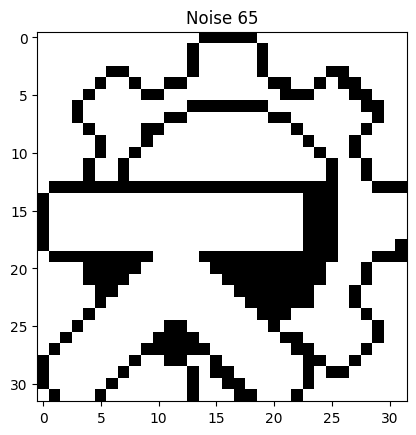

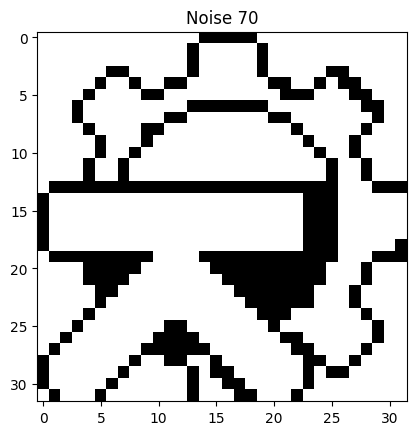

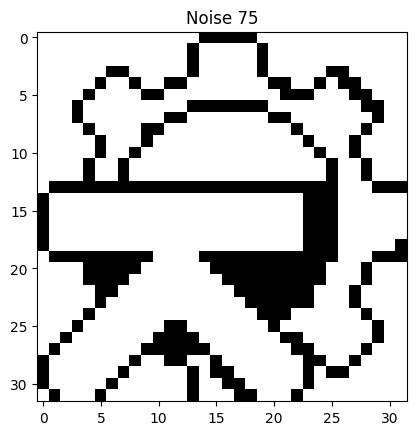

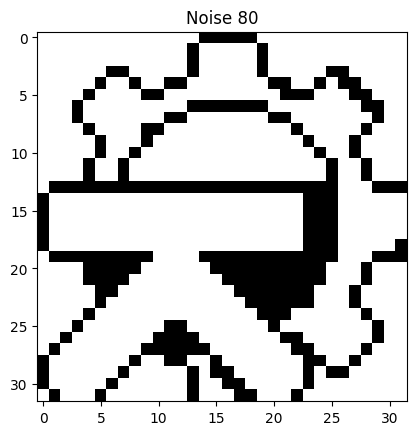

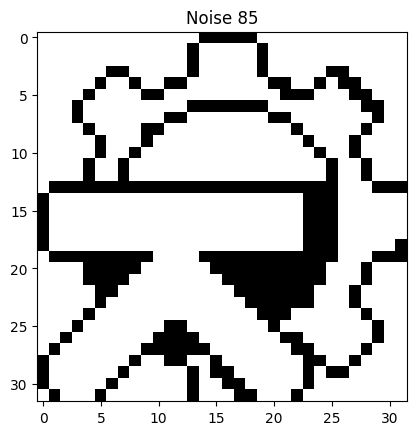

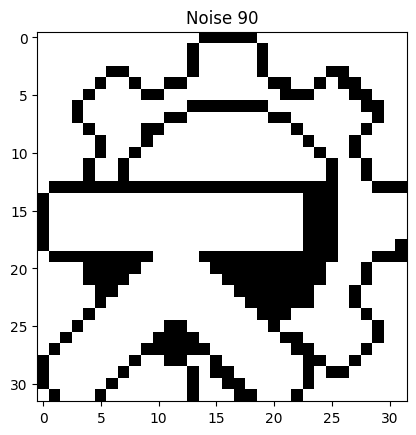

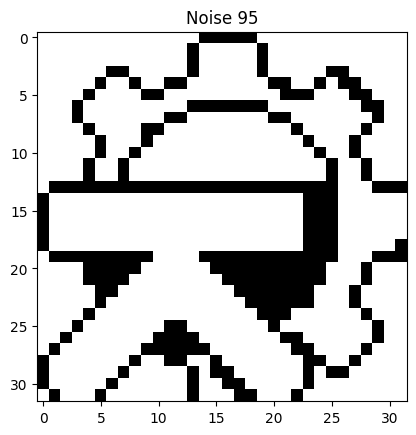

Next P


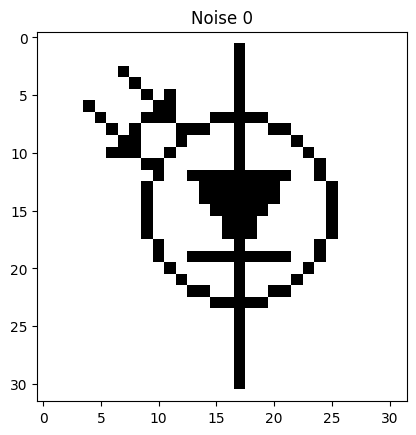

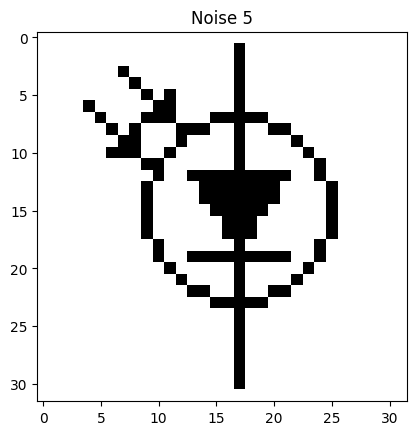

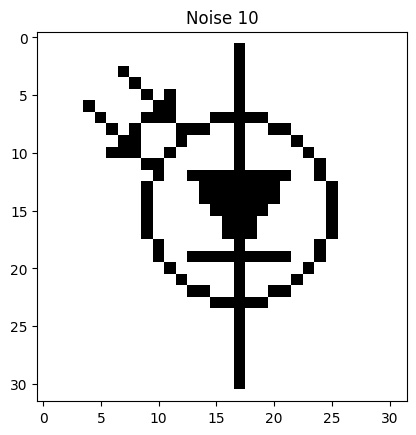

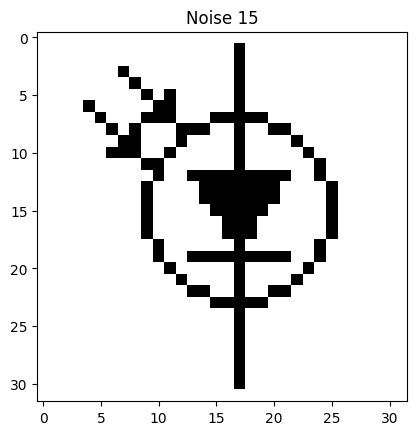

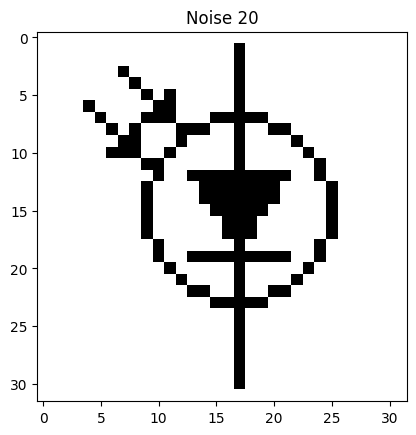

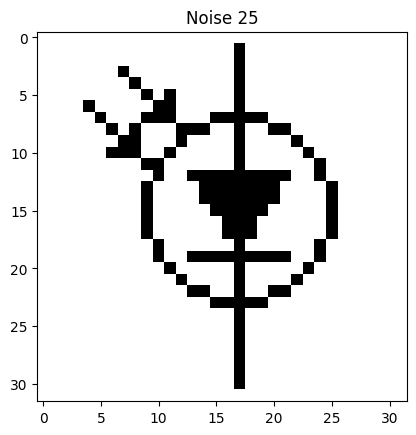

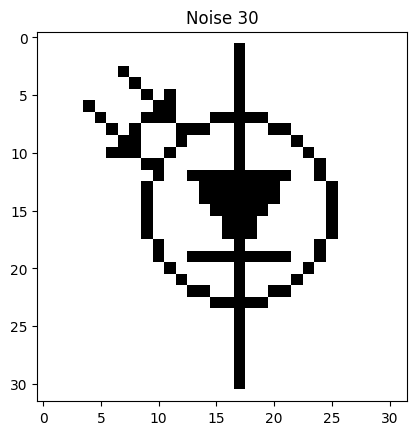

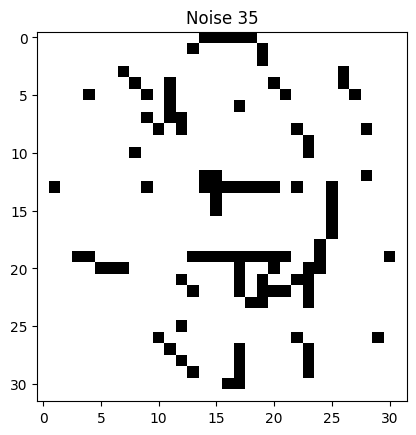

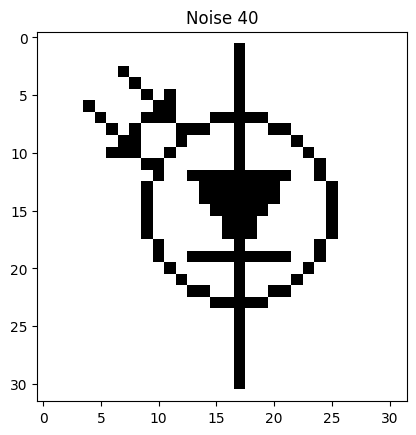

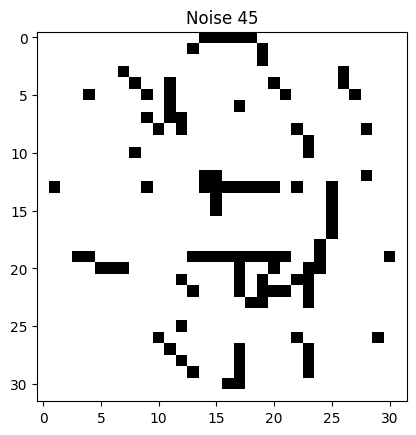

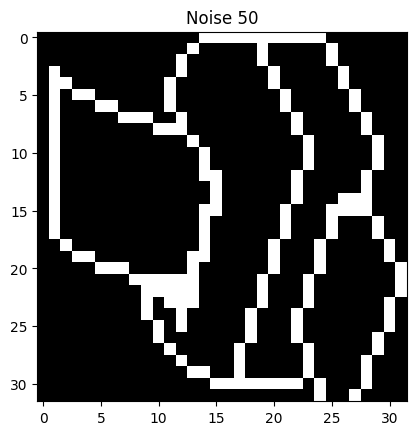

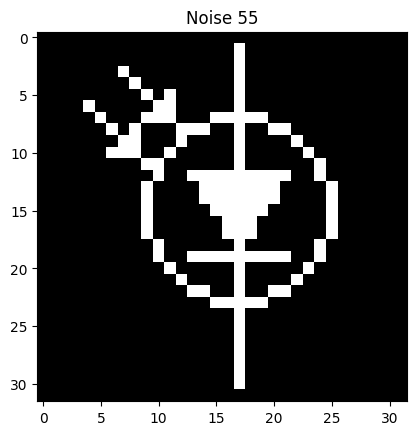

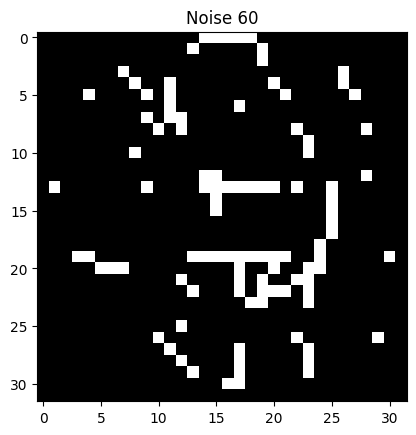

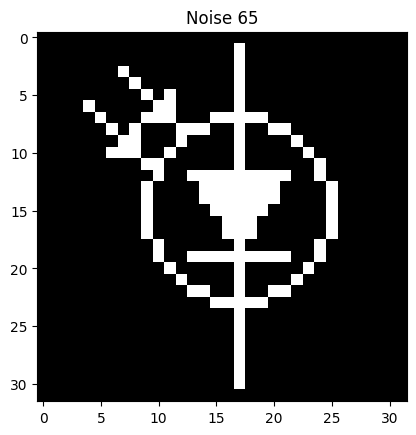

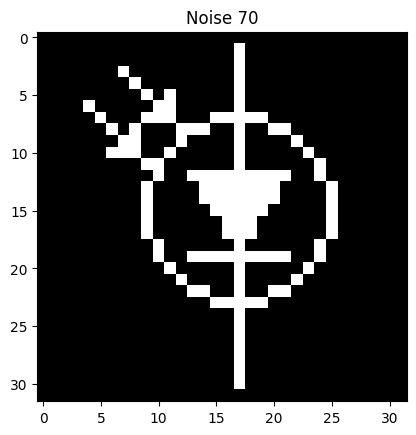

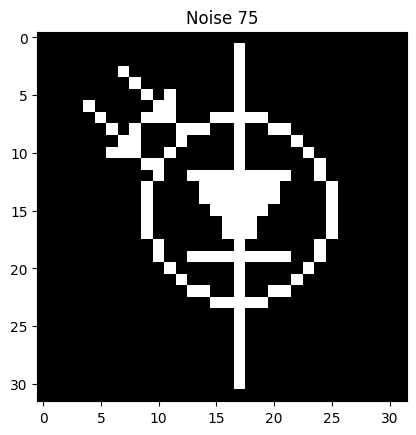

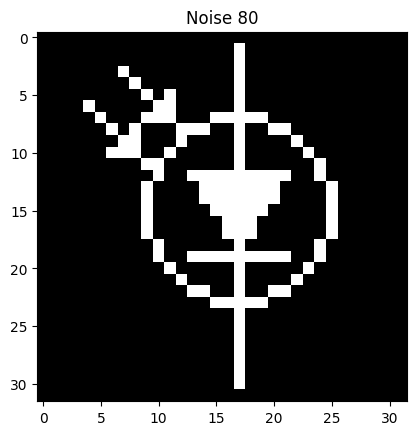

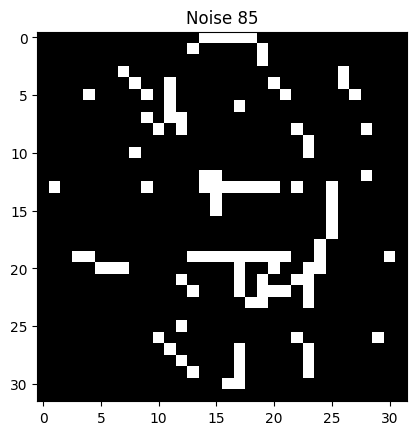

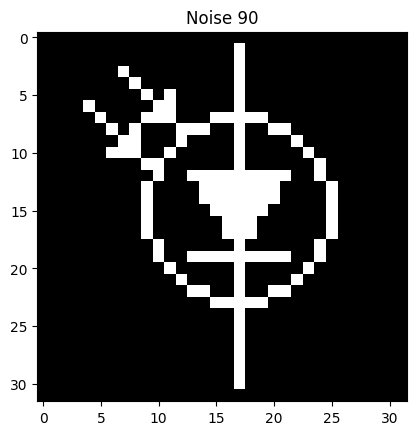

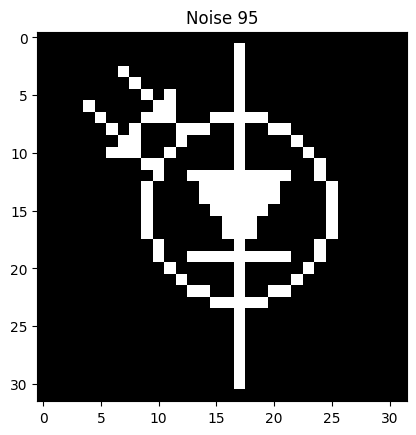

In [182]:
for p in [p1,p2,p3]:
  print('Next P')
  for n in range(0,100,5):
    p_noise = add_noise(p, n)
    p_old = np.zeros(len(p_noise))
    while(not np.array_equal(p_noise,p_old)):
      p_old = p_noise
      p_noise = own_sign(weights @ p_noise)
    plt.imshow(p_noise.reshape(32, 32), cmap='gray')
    plt.title(f"Noise {n}")
    plt.show()

extra iterarions dont help

First one:
*   Noise 30 first distorted
*   Noise 55 inverted image appears

Second one:
*   Noise 25 first distorted
*   Noise 55 inverted image appears

Third one:
*   Noise 35 first distorted
*   Noise 55 inverted image appears

In the intervall mixture between no attractor of the given 3 or one of them three but seemes random

##3.5 Capacity

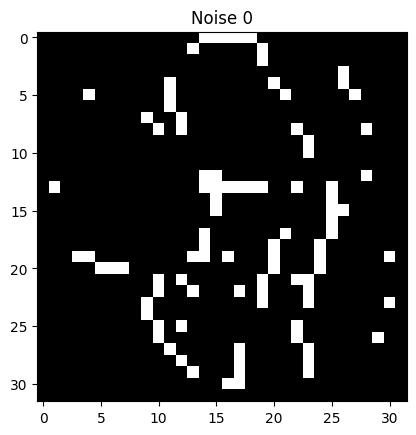

In [200]:
p4 = data[3,:]
p5 = data[4,:]
p6 = data[5,:]
p7 = data[6,:]

weights4 = weights + np.outer(p4,p4)
noise = 0
p_noise = add_noise(p1, noise)
p_old = np.zeros(len(p_noise))
while(not np.array_equal(p_noise,p_old)):
  p_old = p_noise
  p_noise = own_sign(weights4 @ p_noise)
plt.imshow(p_noise.reshape(32, 32), cmap='gray')
plt.title(f"Noise {noise}")
plt.show()

Storage collapsed

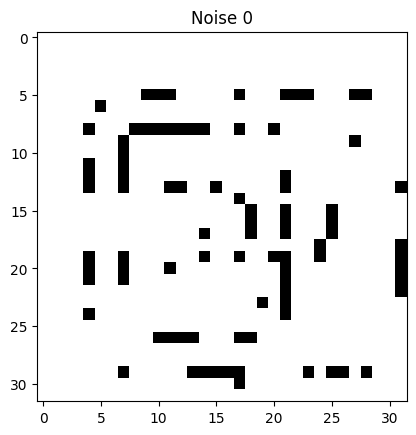

In [202]:
weights5 = weights + np.outer(p5,p5)
noise = 0
p_noise = add_noise(p5, noise)
p_old = np.zeros(len(p_noise))
while(not np.array_equal(p_noise,p_old)):
  p_old = p_noise
  p_noise = own_sign(weights5 @ p_noise)
plt.imshow(p_noise.reshape(32, 32), cmap='gray')
plt.title(f"Noise {noise}")
plt.show()

Also collapses

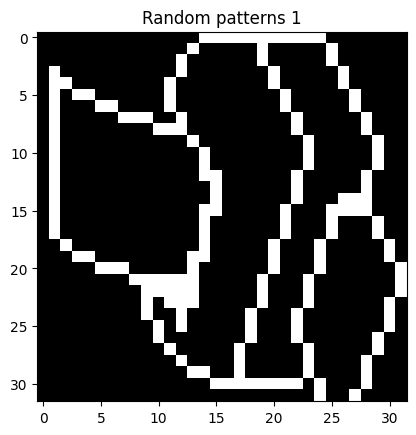

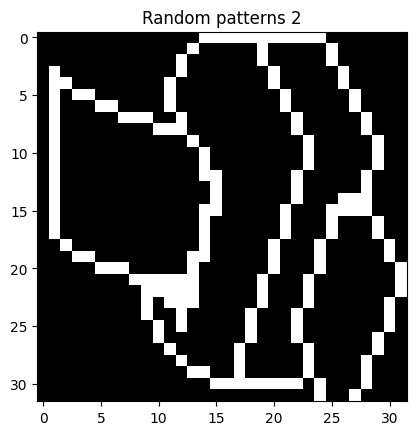

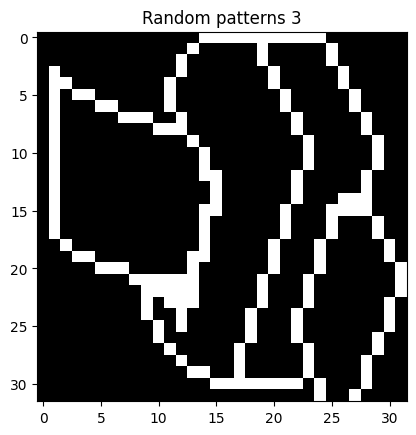

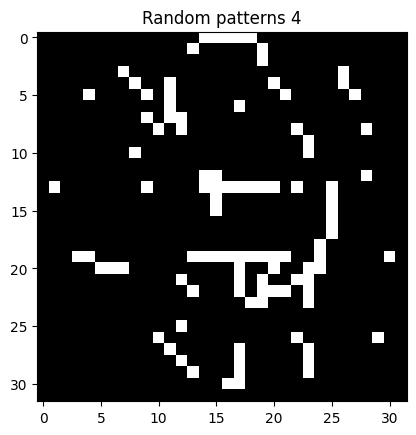

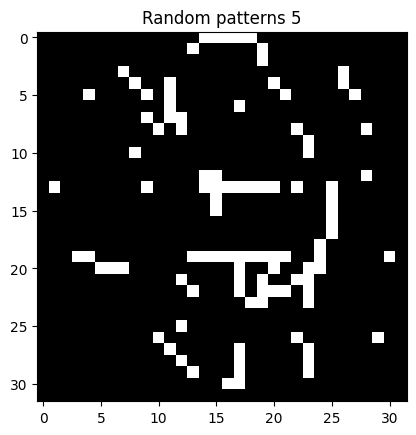

In [211]:
weights_random= weights.copy()
noise = 10
for i in range(1,6):
  p_random = own_sign(np.random.uniform(-1,1,1024))
  weights_random = weights_random + np.outer(p_random,p_random)

  p_noise = add_noise(p1, noise)
  p_old = np.zeros(len(p_noise))
  while(not np.array_equal(p_noise,p_old)):
    p_old = p_noise
    p_noise = own_sign(weights_random @ p_noise)
  plt.imshow(p_noise.reshape(32, 32), cmap='gray')
  plt.title(f"Random patterns {i}")
  plt.show()

Yes I can store 2-3 depending on the noise

The pictures might overlap more and this way take up each others storage capacitys while for the random patterns this shouldnt happen.

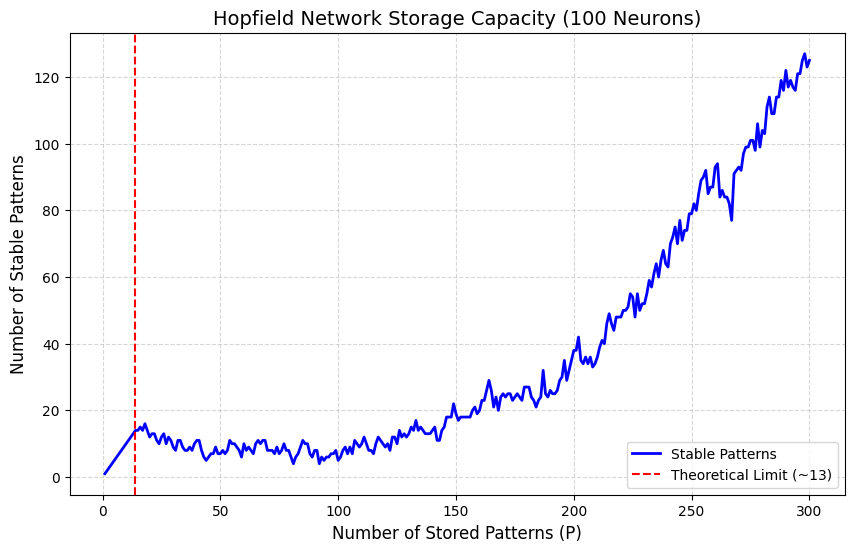

In [218]:
p_random = own_sign(np.random.uniform(-1,1,(300,100)))
stable = []
weights = np.zeros((100,100))
for i in range(300):
  weights = weights + np.outer(p_random[i,:],p_random[i,:])
  stable_count= 0
  for j in range(i+1):
    if(np.array_equal(p_random[j,:],own_sign(weights @ p_random[j,:]))):stable_count +=1
  stable.append(stable_count)


plt.figure(figsize=(10, 6))
plt.plot(range(1, 301), stable, color='blue', linewidth=2, label='Stable Patterns')

plt.title('Hopfield Network Storage Capacity (100 Neurons)', fontsize=14)
plt.xlabel('Number of Stored Patterns (P)', fontsize=12)
plt.ylabel('Number of Stable Patterns', fontsize=12)

# Theoretical capacity limit (0.138 * N)
n_neurons = 100
limit = 0.138 * n_neurons
plt.axvline(x=limit, color='red', linestyle='--', label=f'Theoretical Limit (~{int(limit)})')

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

The number of storad pattens completly colapses to 0

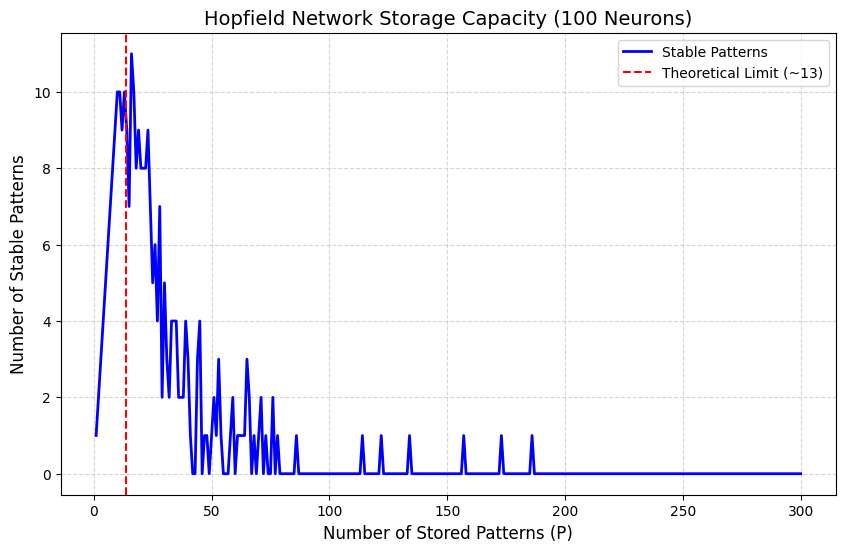

In [221]:
p_random = own_sign(np.random.uniform(-1,1,(300,100)))
stable = []
weights = np.zeros((100,100))
for i in range(300):
  weights = weights + np.outer(p_random[i,:],p_random[i,:])
  stable_count= 0
  for j in range(i+1):
    p_noise = add_noise(p_random[j,:], 5)
    if(np.array_equal(p_random[j,:],own_sign(weights @ p_noise))):stable_count +=1
  stable.append(stable_count)


plt.figure(figsize=(10, 6))
plt.plot(range(1, 301), stable, color='blue', linewidth=2, label='Stable Patterns')

plt.title('Hopfield Network Storage Capacity (100 Neurons)', fontsize=14)
plt.xlabel('Number of Stored Patterns (P)', fontsize=12)
plt.ylabel('Number of Stable Patterns', fontsize=12)

# Theoretical capacity limit (0.138 * N)
n_neurons = 100
limit = 0.138 * n_neurons
plt.axvline(x=limit, color='red', linestyle='--', label=f'Theoretical Limit (~{int(limit)})')

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

The number of storad pattens completly colapses to 0. It means that for big numbers the network probably just tends to keeo the same patter as the one which was inputed which hints to self-connections.

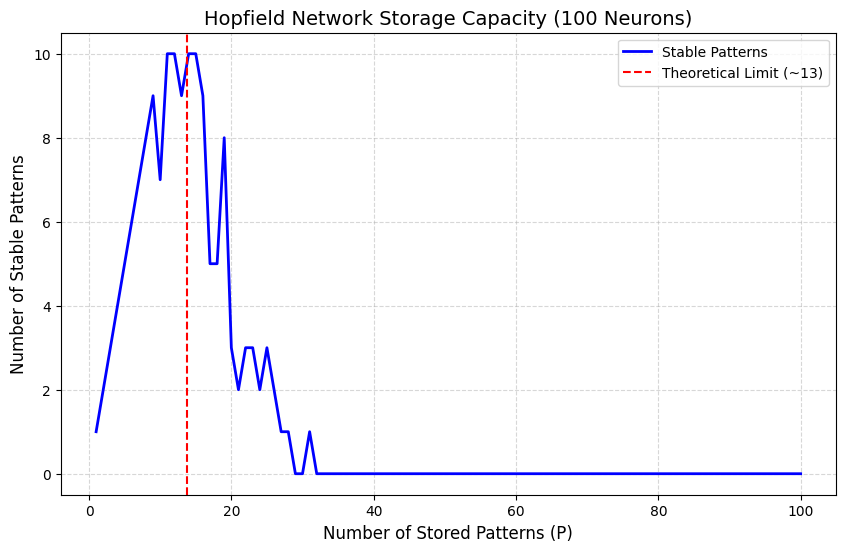

In [225]:
p_random = own_sign(np.random.uniform(-1,1,(300,100)))
stable = []
weights = np.zeros((100,100))
max_number = 100
for i in range(max_number):
  weights = weights + np.outer(p_random[i,:],p_random[i,:])
  np.fill_diagonal(weights, 0)
  stable_count= 0
  for j in range(i+1):
    if(np.array_equal(p_random[j,:],own_sign(weights @ p_random[j,:]))):stable_count +=1
  stable.append(stable_count)


plt.figure(figsize=(10, 6))
plt.plot(range(1, max_number+1), stable, color='blue', linewidth=2, label='Stable Patterns')

plt.title('Hopfield Network Storage Capacity (100 Neurons)', fontsize=14)
plt.xlabel('Number of Stored Patterns (P)', fontsize=12)
plt.ylabel('Number of Stable Patterns', fontsize=12)

# Theoretical capacity limit (0.138 * N)
n_neurons = 100
limit = 0.138 * n_neurons
plt.axvline(x=limit, color='red', linestyle='--', label=f'Theoretical Limit (~{int(limit)})')

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

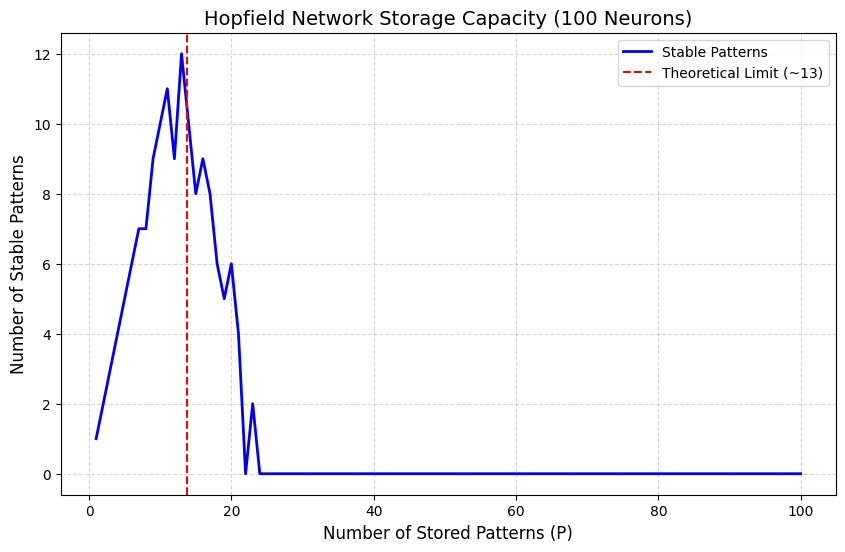

In [226]:
p_random = own_sign(np.random.uniform(-1,1,(300,100)))
stable = []
weights = np.zeros((100,100))
max_number = 100
for i in range(max_number):
  weights = weights + np.outer(p_random[i,:],p_random[i,:])
  np.fill_diagonal(weights, 0)
  stable_count= 0
  for j in range(i+1):
    p_noise = add_noise(p_random[j,:], 5)
    if(np.array_equal(p_random[j,:],own_sign(weights @ p_noise))):stable_count +=1
  stable.append(stable_count)


plt.figure(figsize=(10, 6))
plt.plot(range(1, max_number+1), stable, color='blue', linewidth=2, label='Stable Patterns')

plt.title('Hopfield Network Storage Capacity (100 Neurons)', fontsize=14)
plt.xlabel('Number of Stored Patterns (P)', fontsize=12)
plt.ylabel('Number of Stable Patterns', fontsize=12)

# Theoretical capacity limit (0.138 * N)
n_neurons = 100
limit = 0.138 * n_neurons
plt.axvline(x=limit, color='red', linestyle='--', label=f'Theoretical Limit (~{int(limit)})')

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

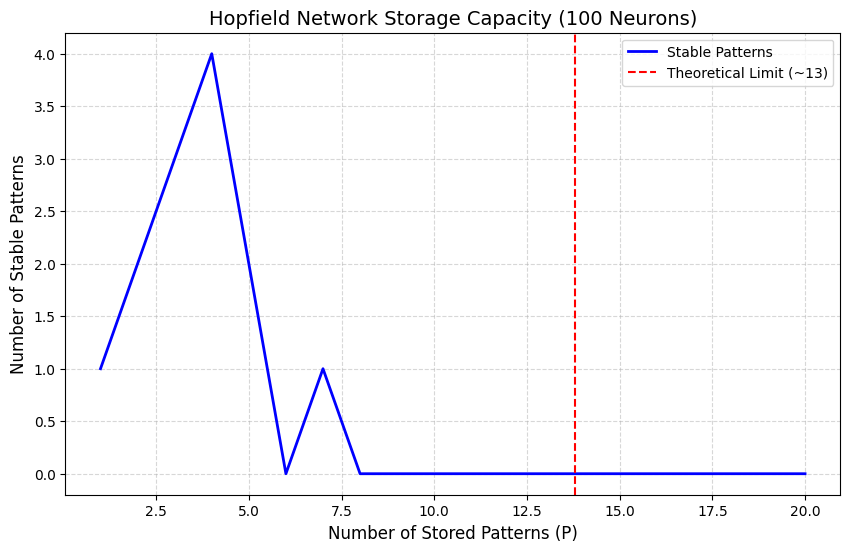

In [230]:
p_random = own_sign(0.5+np.random.uniform(-1,1,(300,100)))
stable = []
weights = np.zeros((100,100))
max_number = 20
for i in range(max_number):
  weights = weights + np.outer(p_random[i,:],p_random[i,:])
  np.fill_diagonal(weights, 0)
  stable_count= 0
  for j in range(i+1):
    p_noise = add_noise(p_random[j,:], 5)
    if(np.array_equal(p_random[j,:],own_sign(weights @ p_noise))):stable_count +=1
  stable.append(stable_count)


plt.figure(figsize=(10, 6))
plt.plot(range(1, max_number+1), stable, color='blue', linewidth=2, label='Stable Patterns')

plt.title('Hopfield Network Storage Capacity (100 Neurons)', fontsize=14)
plt.xlabel('Number of Stored Patterns (P)', fontsize=12)
plt.ylabel('Number of Stable Patterns', fontsize=12)

# Theoretical capacity limit (0.138 * N)
n_neurons = 100
limit = 0.138 * n_neurons
plt.axvline(x=limit, color='red', linestyle='--', label=f'Theoretical Limit (~{int(limit)})')

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

Arround 3-4 patterns can be stored. The patterns are regular so they are biased to one side so this might lover the capacity.